In [2]:
%pip install -U --no-cache-dir ccxt

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jsii 1.106.0 requires attrs<25.0,>=21.2, but you have attrs 26.1.0 which is incompatible.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\crp\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/6.6 MB ? eta -:--:--
   ------ --------------------------------- 1.0/6.6 MB 5.6 MB/s eta 0:00:01
   --------------- ------------------------ 2.6/6.6 MB 6.0 MB/s eta 0:00:01
   ----------------------- ---------------- 3.9/6.6 MB 6.2 MB/s eta 0:00:01
   --------------------------------- ------ 5.5/6.6 MB 6.4 MB/s eta 0:00:01
   -------------------------------------- - 6.3/6.6 MB 6.2 MB/s eta 0:00:01
   -------------------------------------- - 6.3/6.6 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------- 6.6/6.6 MB 5.0 MB/s  0:00:01
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ------------------------------- -------- 1.0/1.3 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 6.2 MB/s  0:00:00
   ---------------------------------------- 0.0/644.5 kB ? eta -:--:--
   ---------------------------------------- 644.5/644.5 kB 6.5 MB/s  0:00:00
   --------------------------------

In [101]:
from __future__ import annotations

from typing import Optional

import ccxt
import pandas as pd


def make_exchange(
    exchange_id: str,
    market_type: str = "spot",
) -> ccxt.Exchange:
    """
    Создаёт объект биржи.

    market_type:
        spot   — спотовый рынок
        swap   — perpetual / бессрочные фьючерсы
        future — фьючерсы с экспирацией
    """
    exchange_id = exchange_id.lower().strip()
    market_type = market_type.lower().strip()

    allowed_market_types = {"spot", "swap", "future"}

    if market_type not in allowed_market_types:
        raise ValueError(
            f"Неизвестный market_type='{market_type}'. "
            f"Допустимо: {sorted(allowed_market_types)}"
        )

    if exchange_id not in ccxt.exchanges:
        raise ValueError(
            f"Биржа '{exchange_id}' не найдена в CCXT.\n"
            f"Примеры: mexc, gate, bybit, okx, binance, kucoin."
        )

    exchange_class = getattr(ccxt, exchange_id)

    exchange = exchange_class({
        "enableRateLimit": True,
        "timeout": 30_000,

        # Указываем CCXT сегмент рынка по умолчанию.
        "options": {
            "defaultType": market_type,
        },
    })

    if not exchange.has.get("fetchOHLCV"):
        raise RuntimeError(
            f"Биржа '{exchange_id}' не поддерживает fetchOHLCV."
        )

    exchange.load_markets()

    return exchange


def resolve_symbol(
    exchange: ccxt.Exchange,
    token: str,
    quote: str = "USDT",
    market_type: str = "spot",
) -> str:
    """
    Ищет символ нужного рынка.

    Примеры:
    spot:
        token='ONE' -> ONE/USDT

    swap:
        token='ONE' -> ONE/USDT:USDT

    Если передать готовый символ, например ONE/USDT:USDT,
    он будет использован напрямую.
    """
    token = token.upper().strip()
    quote = quote.upper().strip()
    market_type = market_type.lower().strip()

    # Если пользователь передал полный символ, используем его.
    if "/" in token:
        symbol = token

        if symbol not in exchange.markets:
            raise ValueError(
                f"На {exchange.id} не найдена пара '{symbol}'."
            )

        market = exchange.market(symbol)

        if market.get("type") != market_type:
            raise ValueError(
                f"На {exchange.id} символ '{symbol}' имеет тип "
                f"'{market.get('type')}', а запрошен '{market_type}'."
            )

        return symbol

    # Находим все рынки с данным base, quote и требуемым типом.
    candidates = []

    for market in exchange.markets.values():
        if (
            market.get("base") == token
            and market.get("quote") == quote
            and market.get("type") == market_type
            and market.get("active", True)
        ):
            candidates.append(market)

    if not candidates:
        raise ValueError(
            f"На {exchange.id} не найден активный {market_type}-рынок "
            f"для {token}/{quote}."
        )

    # Для spot и swap обычно находится одна подходящая пара.
    # Для future с экспирацией контрактов может быть несколько.
    if market_type == "future" and len(candidates) > 1:
        available = [market["symbol"] for market in candidates]

        raise ValueError(
            f"На {exchange.id} найдено несколько futures-контрактов "
            f"для {token}/{quote}:\n{available}\n\n"
            f"Передай полный символ контракта вручную, например:\n"
            f"token_a='{available[0]}'"
        )

    market = candidates[0]

    print(
        f"{exchange.id.upper()}: "
        f"symbol={market['symbol']}, "
        f"type={market['type']}, "
        f"spot={market.get('spot')}, "
        f"swap={market.get('swap')}, "
        f"future={market.get('future')}"
    )

    return market["symbol"]


def fetch_close_prices(
    exchange: ccxt.Exchange,
    symbol: str,
    timeframe: str,
    limit: int,
    since: Optional[int] = None,
    only_closed: bool = True,
) -> pd.DataFrame:
    """
    Получает OHLCV и возвращает таблицу:

    timestamp | close

    При only_closed=True удаляет последнюю незавершённую свечу.
    """
    ohlcv = exchange.fetch_ohlcv(
        symbol=symbol,
        timeframe=timeframe,
        since=since,
        limit=limit,
    )

    if not ohlcv:
        raise RuntimeError(
            f"{exchange.id}: API не вернул свечи для "
            f"{symbol}, timeframe={timeframe}."
        )

    df = pd.DataFrame(
        ohlcv,
        columns=["timestamp", "open", "high", "low", "close", "volume"],
    )

    if only_closed:
        timeframe_ms = exchange.parse_timeframe(timeframe) * 1000
        now_ms = exchange.milliseconds()

        # timestamp — начало свечи.
        # Оставляем только интервалы, которые уже полностью закончились.
        df = df[
            df["timestamp"] + timeframe_ms <= now_ms
        ].copy()

    df = (
        df[["timestamp", "close"]]
        .drop_duplicates(subset="timestamp", keep="last")
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    return df


def get_taker_fee_rate(
    exchange: ccxt.Exchange,
    symbol: str,
) -> tuple[float, str]:
    """
    Возвращает taker-комиссию в долях единицы.

    Пример:
        0.0006 = 0.06%
        0.0010 = 0.10%

    Порядок получения:
    1. fetch_trading_fee(symbol), если биржа это поддерживает;
    2. market['taker'] для конкретного инструмента;
    3. exchange.fees['trading']['taker'];
    4. ошибка, если ставку определить не удалось.
    """
    market = exchange.market(symbol)

    # 1. Попытка получить fee endpoint для конкретного symbol.
    if exchange.has.get("fetchTradingFee"):
        try:
            fee_info = exchange.fetch_trading_fee(symbol)
            taker_fee = fee_info.get("taker")

            if taker_fee is not None:
                return float(taker_fee), "fetch_trading_fee"

        except Exception as error:
            print(
                f"Предупреждение: {exchange.id} не вернула "
                f"fetch_trading_fee для {symbol}: "
                f"{type(error).__name__}"
            )

    # 2. Ставка taker для конкретного рынка.
    market_taker_fee = market.get("taker")

    if market_taker_fee is not None:
        return float(market_taker_fee), "market['taker']"

    # 3. Общая опубликованная ставка биржи.
    exchange_taker_fee = (
        exchange.fees
        .get("trading", {})
        .get("taker")
    )

    if exchange_taker_fee is not None:
        return float(exchange_taker_fee), "exchange.fees['trading']['taker']"

    raise RuntimeError(
        f"Не удалось определить taker-комиссию для "
        f"{exchange.id} | {symbol}."
    )



def get_synchronized_close_arrays(
    exchange_a_id: str,
    token_a: str,
    exchange_b_id: str,
    token_b: str,
    timeframe: str = "5m",
    limit: int = 500,
    quote: str = "USDT",
    market_type: str = "spot",
    since: Optional[int] = None,
    only_closed: bool = True,
) -> tuple[list[tuple[float, float]], pd.DataFrame]:
    """
    Возвращает:

    pairs:
        [(close_a_0, close_b_0), (close_a_1, close_b_1), ...]

    synced_df:
        timestamp
        close_a
        close_b
        datetime_utc
        taker_fee_rate_a
        taker_fee_rate_b
        taker_fee_bps_a
        taker_fee_bps_b

    Комиссии сохраняются в DataFrame, чтобы бэктест мог
    автоматически использовать реальные ставки CCXT.
    """
    market_type = market_type.lower().strip()

    exchange_a = make_exchange(
        exchange_id=exchange_a_id,
        market_type=market_type,
    )

    exchange_b = make_exchange(
        exchange_id=exchange_b_id,
        market_type=market_type,
    )

    symbol_a = resolve_symbol(
        exchange=exchange_a,
        token=token_a,
        quote=quote,
        market_type=market_type,
    )

    symbol_b = resolve_symbol(
        exchange=exchange_b,
        token=token_b,
        quote=quote,
        market_type=market_type,
    )

    # Получаем taker fee отдельно для каждой биржи и инструмента.
    taker_fee_rate_a, fee_source_a = get_taker_fee_rate(
        exchange=exchange_a,
        symbol=symbol_a,
    )

    taker_fee_rate_b, fee_source_b = get_taker_fee_rate(
        exchange=exchange_b,
        symbol=symbol_b,
    )

    print(f"\nЗапрос A: {exchange_a.id} | {symbol_a} | {market_type} | {timeframe}")
    print(f"Запрос B: {exchange_b.id} | {symbol_b} | {market_type} | {timeframe}")

    print(
        f"\nКомиссия A ({exchange_a.id}, taker): "
        f"{taker_fee_rate_a * 100:.5f}% "
        f"= {taker_fee_rate_a * 10_000:.2f} bps "
        f"| источник: {fee_source_a}"
    )

    print(
        f"Комиссия B ({exchange_b.id}, taker): "
        f"{taker_fee_rate_b * 100:.5f}% "
        f"= {taker_fee_rate_b * 10_000:.2f} bps "
        f"| источник: {fee_source_b}"
    )

    candles_a = fetch_close_prices(
        exchange=exchange_a,
        symbol=symbol_a,
        timeframe=timeframe,
        limit=limit,
        since=since,
        only_closed=only_closed,
    )

    candles_b = fetch_close_prices(
        exchange=exchange_b,
        symbol=symbol_b,
        timeframe=timeframe,
        limit=limit,
        since=since,
        only_closed=only_closed,
    )

    candles_a = candles_a.rename(columns={"close": "close_a"})
    candles_b = candles_b.rename(columns={"close": "close_b"})

    synced_df = candles_a.merge(
        candles_b,
        on="timestamp",
        how="inner",
        validate="one_to_one",
    )

    synced_df = (
        synced_df
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    synced_df["datetime_utc"] = pd.to_datetime(
        synced_df["timestamp"],
        unit="ms",
        utc=True,
    )

    # Служебные колонки: их увидит бэктест независимо от copy(),
    # slice(), calculate_rolling_zscore() и dashboard.
    synced_df["taker_fee_rate_a"] = taker_fee_rate_a
    synced_df["taker_fee_rate_b"] = taker_fee_rate_b
  fee_bps_per_leg: float = 10.0,
    synced_df["taker_fee_bps_a"] = taker_fee_rate_a * 10_000
    synced_df["taker_fee_bps_b"] = taker_fee_rate_b * 10_000

    # Полезные метаданные для проверки отчёта.
    synced_df.attrs["exchange_a_id"] = exchange_a.id
    synced_df.attrs["exchange_b_id"] = exchange_b.id
    synced_df.attrs["symbol_a"] = symbol_a
    synced_df.attrs["symbol_b"] = symbol_b
    synced_df.attrs["market_type"] = market_type

    close_prices_a = synced_df["close_a"].to_list()
    close_prices_b = synced_df["close_b"].to_list()

    pairs = list(zip(close_prices_a, close_prices_b))
  fee_bps_per_leg: float = 10.0,
    return pairs, synced_df

In [91]:
pairs, data = get_synchronized_close_arrays(
    exchange_a_id="mexc",
    token_a="BDX",
    exchange_b_id="gate",
    token_b="ONE",
    timeframe="5m",
    limit=1000,
    quote="USDT",
    market_type="swap",
)

MEXC: symbol=BDX/USDT:USDT, type=swap, spot=False, swap=True, future=False
GATE: symbol=ONE/USDT:USDT, type=swap, spot=False, swap=True, future=False

Запрос A: mexc | BDX/USDT:USDT | swap | 5m
Запрос B: gate | ONE/USDT:USDT | swap | 5m


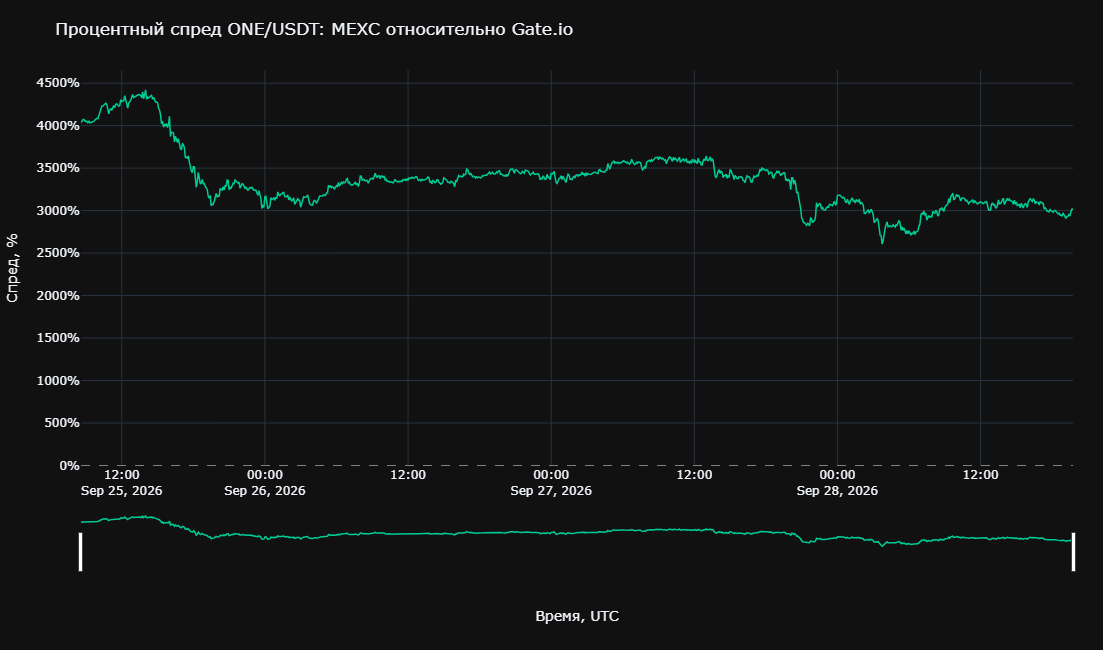

In [92]:
import plotly.graph_objects as go

# `data` уже был создан в твоём коде:
# pairs, data = get_synchronized_close_arrays(...)

# Создаём отдельную копию, исходный data не изменяем.
plot_data = data.copy()

# Процентный спред:
# MEXC относительно Gate.io.
plot_data["spread_percent"] = (
    (plot_data["close_a"] / plot_data["close_b"] - 1) * 100
)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=plot_data["datetime_utc"],
        y=plot_data["spread_percent"],
        mode="lines",
        name="MEXC относительно Gate.io",
        line=dict(
            color="#00CC96",
            width=1.5,
        ),

        # close_a = MEXC, close_b = Gate,
        # timestamp добавлен только для информативной подсказки.
        customdata=plot_data[
            ["close_a", "close_b", "timestamp"]
        ].to_numpy(),

        hovertemplate=(
            "<b>Время: %{x}</b><br>"
            "Спред: %{y:.6f}%<br>"
            "MEXC close: %{customdata[0]:.10f} USDT<br>"
            "Gate close: %{customdata[1]:.10f} USDT<br>"
            "Timestamp: %{customdata[2]}"
            "<extra></extra>"
        ),
    )
)

# Нулевая линия: точки равенства цен двух бирж.
fig.add_hline(
    y=0,
    line_width=1,
    line_dash="dash",
    line_color="gray",
)

fig.update_layout(
    title="Процентный спред ONE/USDT: MEXC относительно Gate.io",
    template="plotly_dark",
    height=650,

    # ЛКМ перемещает временной ряд.
    dragmode="pan",

    # Показывает одно всплывающее значение на выбранном timestamp.
    hovermode="x unified",

    margin=dict(l=80, r=30, t=70, b=60),

    xaxis=dict(
        title="Время, UTC",
        type="date",

        # Нижний интерактивный ползунок по времени.
        rangeslider=dict(visible=True),
    ),

    yaxis=dict(
        title="Спред, %",
        zeroline=False,
        ticksuffix="%",
    ),
)

fig.show(
    config={
        "scrollZoom": True,   # Масштабирование колёсиком мыши.
        "displaylogo": False,
    }
)

In [38]:
import plotly.graph_objects as go


def plot_spread_zscore(
    data,
    window: int = 50,
    height: int = 700,
    exchange_a_name: str = "Биржа A",
    exchange_b_name: str = "Биржа B",
):
    """
    Строит интерактивный график rolling Z-score абсолютного спреда.

    Параметры:
        data:
            DataFrame с колонками:
            timestamp, datetime_utc, close_a, close_b

        window:
            Число свечей в скользящем окне для среднего и std.
            Например:
            50 свечей * 5 минут = 250 минут = 4 часа 10 минут.

        height:
            Высота графика в пикселях.
            Например: 500, 700, 1000, 1400.

        exchange_a_name:
            Название первой биржи для подписей.

        exchange_b_name:
            Название второй биржи для подписей.
    """
    if window < 2:
        raise ValueError("window должен быть не меньше 2.")

    required_columns = {
        "timestamp",
        "datetime_utc",
        "close_a",
        "close_b",
    }

    missing_columns = required_columns - set(data.columns)

    if missing_columns:
        raise ValueError(
            f"В data отсутствуют нужные колонки: {missing_columns}"
        )

    plot_data = data.copy()

    # Абсолютный ценовой спред в USDT.
    # Не модуль: знак сохраняется.
    plot_data["spread"] = (
        plot_data["close_a"] - plot_data["close_b"]
    )

    # Скользящее среднее спреда.
    plot_data["spread_mean"] = (
        plot_data["spread"]
        .rolling(window=window, min_periods=window)
        .mean()
    )

    # Скользящее стандартное отклонение спреда.
    plot_data["spread_std"] = (
        plot_data["spread"]
        .rolling(window=window, min_periods=window)
        .std(ddof=0)
    )

    # Z-score:
    # (текущий спред - средний спред за window свечей) / std.
    plot_data["z_score"] = (
        (plot_data["spread"] - plot_data["spread_mean"])
        / plot_data["spread_std"]
    )

    # Если std = 0 или появляются бесконечности — удаляем такие строки.
    plot_data = (
        plot_data
        .replace([float("inf"), float("-inf")], None)
        .dropna(subset=["z_score"])
        .reset_index(drop=True)
    )

    if plot_data.empty:
        raise ValueError(
            "После расчёта не осталось данных. "
            "Уменьши window или запроси больше свечей."
        )

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=plot_data["datetime_utc"],
            y=plot_data["z_score"],
            mode="lines",
            name="Z-score спреда",
            line=dict(
                color="#00CC96",
                width=1.5,
            ),

            # Дополнительные данные во всплывающем окне.
            customdata=plot_data[
                [
                    "spread",
                    "spread_mean",
                    "spread_std",
                    "close_a",
                    "close_b",
                ]
            ].to_numpy(),

            hovertemplate=(
                "<b>Время: %{x}</b><br>"
                "Z-score: %{y:.4f}<br>"
                "Спред: %{customdata[0]:.10f} USDT<br>"
                f"{exchange_a_name}: %{{customdata[3]:.10f}} USDT<br>"
                f"{exchange_b_name}: %{{customdata[4]:.10f}} USDT<br>"
                "Rolling mean: %{customdata[1]:.10f}<br>"
                "Rolling std: %{customdata[2]:.10f}"
                "<extra></extra>"
            ),
        )
    )

    # Центральная линия: текущий спред равен скользящему среднему.
    fig.add_hline(
        y=0,
        line_width=1,
        line_dash="dash",
        line_color="gray",
    )

    # Границы ±1σ.
    fig.add_hline(
        y=1,
        line_width=1,
        line_dash="dot",
        line_color="#4C78A8",
        annotation_text="+1σ",
        annotation_position="top left",
    )

    fig.add_hline(
        y=-1,
        line_width=1,
        line_dash="dot",
        line_color="#4C78A8",
        annotation_text="−1σ",
        annotation_position="bottom left",
    )

    # Часто используемые уровни отклонения.
    fig.add_hline(
        y=2,
        line_width=1,
        line_dash="dash",
        line_color="#EF553B",
        annotation_text="+2σ",
        annotation_position="top left",
    )

    fig.add_hline(
        y=-2,
        line_width=1,
        line_dash="dash",
        line_color="#EF553B",
        annotation_text="−2σ",
        annotation_position="bottom left",
    )

    fig.update_layout(
        title=(
            f"Rolling Z-score спреда: "
            f"{exchange_a_name} − {exchange_b_name} | "
            f"Окно: {window} свечей"
        ),
        template="plotly_dark",

        # Управление вертикальным размером графика.
        height=height,

        # Перемещение графика ЛКМ.
        dragmode="pan",

        hovermode="x unified",

        margin=dict(l=80, r=30, t=70, b=60),

        xaxis=dict(
            title="Время, UTC",
            type="date",
            rangeslider=dict(visible=True),
        ),

        yaxis=dict(
            title="Z-score",
            zeroline=False,
        ),
    )

    fig.show(
        config={
            "scrollZoom": True,
            "displaylogo": False,
            "responsive": True,
        }
    )

    return plot_data

In [57]:
import ipywidgets as widgets
from IPython.display import display, clear_output


def interactive_zscore_chart(
    data,
    exchange_a_name: str = "MEXC",
    exchange_b_name: str = "Gate.io",
    initial_window: int = 300,
    height: int = 500,
):
    """
    Интерактивный Z-score с ползунком window.

    При движении ползунка пересчитывается rolling mean,
    rolling std и Z-score, но новые данные с бирж не запрашиваются.
    """

    max_window = min(len(data) - 1, 500)

    if max_window < 2:
        raise ValueError(
            "В data слишком мало строк для расчёта Z-score."
        )

    # Если данных меньше, чем initial_window,
    # устанавливаем максимально допустимое окно.
    initial_window = min(initial_window, max_window)

    window_slider = widgets.IntSlider(
        value=initial_window,
        min=2,
        max=max_window,
        step=1,
        description="Window:",
        continuous_update=False,
        style={"description_width": "initial"},
        layout=widgets.Layout(width="800px"),
    )

    height_slider = widgets.IntSlider(
        value=height,
        min=300,
        max=1400,
        step=50,
        description="Высота графика:",
        continuous_update=False,
        style={"description_width": "initial"},
        layout=widgets.Layout(width="800px"),
    )

    info = widgets.HTML()

    output = widgets.Output()

    def update_chart(change=None):
        window = window_slider.value
        chart_height = height_slider.value

        timeframe_minutes = 5
        hours = window * timeframe_minutes / 60

        info.value = (
            f"<b>Окно:</b> {window} свечей "
            f"≈ {hours:.2f} ч "
            f"({window * timeframe_minutes} минут)"
        )

        with output:
            clear_output(wait=True)

            plot_spread_zscore(
                data=data,
                window=window,
                height=chart_height,
                exchange_a_name=exchange_a_name,
                exchange_b_name=exchange_b_name,
            )

    window_slider.observe(update_chart, names="value")
    height_slider.observe(update_chart, names="value")

    controls = widgets.VBox([
        window_slider,
        height_slider,
        info,
    ])

    display(controls, output)

    # Строит начальный график.
    update_chart()

    return window_slider, height_slider

In [93]:
window_slider, height_slider = interactive_zscore_chart(
    data=data,
    exchange_a_name="MEXC",
    exchange_b_name="Gate.io",
    initial_window=300,
    height=500,
)

Output()

# Подбор оптимальных параметров (rolling window) и бэктест для токена ONE

In [61]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional

import numpy as np
import pandas as pd

In [62]:
@dataclass
class BacktestResult:
    trades: pd.DataFrame
    equity_curve: pd.DataFrame
    metrics: dict

In [63]:
def calculate_rolling_zscore(
    data: pd.DataFrame,
    window: int,
) -> pd.DataFrame:
    """
    Рассчитывает абсолютный спред и rolling Z-score.

    spread = close_a - close_b

    Важно:
    rolling mean и rolling std используют только текущую
    и прошлые свечи. Будущие свечи не используются.
    """
    if window < 2:
        raise ValueError("window должен быть не меньше 2.")

    result = data.copy()

    result["spread"] = (
        result["close_a"] - result["close_b"]
    )

    result["spread_mean"] = (
        result["spread"]
        .rolling(window=window, min_periods=window)
        .mean()
    )

    result["spread_std"] = (
        result["spread"]
        .rolling(window=window, min_periods=window)
        .std(ddof=0)
    )

    result["z_score"] = (
        (result["spread"] - result["spread_mean"])
        / result["spread_std"]
    )

    result = result.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    return result

In [102]:
def backtest_zscore_strategy(
    data: pd.DataFrame,
    window: int,
    long_entry_z: float = -1.5,
    short_entry_z: float = 2.0,
    exit_z: float = 0.0,
    stop_z: float = 4.0,
    gross_notional_usdt: float = 1_000.0,
    fee_bps_per_leg: Optional[float] = None,
    slippage_bps_per_leg: float = 5.0,
) -> BacktestResult:
    """
    Event-driven backtest статистического арбитража.

    Входные параметры:
        window:
            Размер rolling-окна для среднего и std спреда.

        long_entry_z:
            Уровень открытия long spread.
            Пример: -1.5.

        short_entry_z:
            Уровень открытия short spread.
            Пример: +2.0.

        exit_z:
            Уровень закрытия при возврате к среднему.
            Обычно 0.0.

        stop_z:
            Аварийное закрытие, если abs(Z-score) слишком велик.
            Пример: 4.0.

        gross_notional_usdt:
            Общий объём позиции в USDT.
            1 000 USDT означает:
            - 500 USDT в long-ноге;
            - 500 USDT в short-ноге.

        fee_bps_per_leg:
            Комиссия одной ноги в базисных пунктах.
            10 bps = 0.10%.

        slippage_bps_per_leg:
            Проскальзывание одной ноги в базисных пунктах.
            5 bps = 0.05%.

    Механика:
        1. Сигнал возникает на закрытии свечи t.
        2. Исполнение моделируется на следующей свече t + 1.
        3. Это исключает исполнение по цене, которая участвовала
           в формировании сигнала.

    Возвращает:
        BacktestResult с trades, equity_curve и metrics.
    """
    if long_entry_z >= exit_z:
        raise ValueError(
            "long_entry_z должен быть меньше exit_z. "
            "Например: long_entry_z=-1.5, exit_z=0."
        )

    if short_entry_z <= exit_z:
        raise ValueError(
            "short_entry_z должен быть больше exit_z. "
            "Например: short_entry_z=2.0, exit_z=0."
        )

    if stop_z <= max(abs(long_entry_z), abs(short_entry_z)):
        raise ValueError(
            "stop_z должен быть больше модулей entry-порогов."
        )

    if gross_notional_usdt <= 0:
        raise ValueError("gross_notional_usdt должен быть больше нуля.")

    df = calculate_rolling_zscore(
        data=data,
        window=window,
    ).reset_index(drop=True)

        # ---------------------------------------------------------
    # Комиссии конкретных бирж.
    #
    # Приоритет:
    # 1. taker_fee_rate_a / taker_fee_rate_b в data;
    # 2. старый параметр fee_bps_per_leg как fallback.
    # ---------------------------------------------------------

    has_ccxt_fees = (
        "taker_fee_rate_a" in df.columns
        and "taker_fee_rate_b" in df.columns
        and df["taker_fee_rate_a"].notna().all()
        and df["taker_fee_rate_b"].notna().all()
    )

    if has_ccxt_fees:
        fee_rate_a = float(df["taker_fee_rate_a"].iloc[0])
        fee_rate_b = float(df["taker_fee_rate_b"].iloc[0])

        fee_source = "CCXT: отдельная taker-комиссия каждой биржи"

    else:
        if fee_bps_per_leg is None:
            raise ValueError(
                "В data нет колонок taker_fee_rate_a / taker_fee_rate_b, "
                "а fallback fee_bps_per_leg не задан."
            )

        fee_rate_a = fee_bps_per_leg / 10_000
        fee_rate_b = fee_bps_per_leg / 10_000

        fee_source = "Ручной fallback fee_bps_per_leg"

    # Проскальзывание пока задаётся вручную и применяется к каждой ноге.
    slippage_rate_per_leg = slippage_bps_per_leg / 10_000

    # Общий notional делится на две равные по USDT ноги.
    leg_notional = gross_notional_usdt / 2

    # Вход: MEXC leg + KuCoin leg.
    entry_cost = (
        leg_notional * (fee_rate_a + slippage_rate_per_leg)
        + leg_notional * (fee_rate_b + slippage_rate_per_leg)
    )

    # Выход аналогичен входу: ещё две операции.
    exit_cost = (
        leg_notional * (fee_rate_a + slippage_rate_per_leg)
        + leg_notional * (fee_rate_b + slippage_rate_per_leg)
    )
    position: Optional[str] = None
    entry_index: Optional[int] = None
    entry_time = None
    entry_z = None
    entry_price_a = None
    entry_price_b = None
    quantity_a = None
    quantity_b = None
    entry_cost = 0.0

    realized_pnl = 0.0
    trades = []
    equity_rows = []

    # Последняя строка не используется как источник сигнала:
    # нам нужна следующая свеча для исполнения t + 1.
    for i in range(len(df) - 1):
        signal_row = df.iloc[i]
        fill_row = df.iloc[i + 1]

        timestamp = signal_row["timestamp"]
        datetime_utc = signal_row["datetime_utc"]
        z = signal_row["z_score"]

        # Пока нет достаточной истории для Z-score.
        if pd.isna(z):
            equity_rows.append({
                "timestamp": timestamp,
                "datetime_utc": datetime_utc,
                "z_score": z,
                "position": position or "flat",
                "realized_pnl_usdt": realized_pnl,
                "equity_usdt": realized_pnl,
            })
            continue

        fill_price_a = float(fill_row["close_a"])
        fill_price_b = float(fill_row["close_b"])
        fill_time = fill_row["datetime_utc"]

        # ---------------------------------------------------------
        # 1. Открытие позиции на следующей закрытой свече.
        # ---------------------------------------------------------
        if position is None:

            if z <= long_entry_z:
                position = "long_spread"

                entry_index = i + 1
                entry_time = fill_time
                entry_z = float(z)

                entry_price_a = fill_price_a
                entry_price_b = fill_price_b

                quantity_a = leg_notional / entry_price_a
                quantity_b = leg_notional / entry_price_b


            elif z >= short_entry_z:
                position = "short_spread"

                entry_index = i + 1
                entry_time = fill_time
                entry_z = float(z)

                entry_price_a = fill_price_a
                entry_price_b = fill_price_b

                quantity_a = leg_notional / entry_price_a
                quantity_b = leg_notional / entry_price_b

                entry_cost = gross_notional_usdt * one_leg_cost_rate

        # ---------------------------------------------------------
        # 2. Проверка условий закрытия позиции.
        # ---------------------------------------------------------
        else:
            exit_reason = None

            if position == "long_spread":
                if z >= exit_z:
                    exit_reason = "mean_reversion"

                elif z <= -abs(stop_z):
                    exit_reason = "stop_z"

            elif position == "short_spread":
                if z <= exit_z:
                    exit_reason = "mean_reversion"

                elif z >= abs(stop_z):
                    exit_reason = "stop_z"

            if exit_reason is not None:
                exit_price_a = fill_price_a
                exit_price_b = fill_price_b

                # Long spread:
                # long A + short B.
                if position == "long_spread":
                    gross_pnl = (
                        quantity_a * (exit_price_a - entry_price_a)
                        + quantity_b * (entry_price_b - exit_price_b)
                    )

                # Short spread:
                # short A + long B.
                else:
                    gross_pnl = (
                        quantity_a * (entry_price_a - exit_price_a)
                        + quantity_b * (exit_price_b - entry_price_b)
                    )

                

                net_pnl = gross_pnl - entry_cost - exit_cost
                realized_pnl += net_pnl

                holding_bars = (i + 1) - entry_index

                trades.append({
                    "direction": position,
                    "entry_time": entry_time,
                    "exit_time": fill_time,
                    "entry_index": entry_index,
                    "exit_index": i + 1,

                    "entry_z": entry_z,
                    "exit_z": float(z),
                    "exit_reason": exit_reason,

                    "entry_price_a": entry_price_a,
                    "entry_price_b": entry_price_b,
                    "exit_price_a": exit_price_a,
                    "exit_price_b": exit_price_b,

                    "gross_pnl_usdt": gross_pnl,
                    "entry_cost_usdt": entry_cost,
                    "exit_cost_usdt": exit_cost,
                    "total_cost_usdt": entry_cost + exit_cost,
                    "net_pnl_usdt": net_pnl,

                    "return_percent_on_gross": (
                        net_pnl / gross_notional_usdt * 100
                    ),

                    "holding_bars": holding_bars,
                })

                position = None
                entry_index = None
                entry_time = None
                entry_z = None
                entry_price_a = None
                entry_price_b = None
                quantity_a = None
                quantity_b = None
                entry_cost = 0.0

        equity_rows.append({
            "timestamp": timestamp,
            "datetime_utc": datetime_utc,
            "z_score": z,
            "position": position or "flat",
            "realized_pnl_usdt": realized_pnl,
            "equity_usdt": realized_pnl,
        })

    trades_df = pd.DataFrame(trades)
    equity_df = pd.DataFrame(equity_rows)

    if trades_df.empty:
            metrics = {
        "window": window,
        "long_entry_z": long_entry_z,
        "short_entry_z": short_entry_z,
        "exit_z": exit_z,
        "stop_z": stop_z,
        "gross_notional_usdt": gross_notional_usdt,

        "taker_fee_rate_a": fee_rate_a,
        "taker_fee_rate_b": fee_rate_b,

        "taker_fee_bps_a": fee_rate_a * 10_000,
        "taker_fee_bps_b": fee_rate_b * 10_000,

        "slippage_bps_per_leg": slippage_bps_per_leg,

        "fee_source": fee_source,

        "trade_count": len(trades_df),
        "net_profit_usdt": trades_df["net_pnl_usdt"].sum(),

        return BacktestResult(
            trades=trades_df,
            equity_curve=equity_df,
            metrics=metrics,
        )

    equity_series = trades_df["net_pnl_usdt"].cumsum()
    equity_peak = equity_series.cummax()
    drawdown = equity_series - equity_peak

    winning_trades = trades_df[
        trades_df["net_pnl_usdt"] > 0
    ]

    losing_trades = trades_df[
        trades_df["net_pnl_usdt"] < 0
    ]

    gross_profit = winning_trades["net_pnl_usdt"].sum()
    gross_loss = abs(losing_trades["net_pnl_usdt"].sum())

    profit_factor = (
        gross_profit / gross_loss
        if gross_loss > 0
        else np.inf
    )

    metrics = {
        "window": window,
        "long_entry_z": long_entry_z,
        "short_entry_z": short_entry_z,
        "exit_z": exit_z,
        "stop_z": stop_z,
        "gross_notional_usdt": gross_notional_usdt,

        "trade_count": len(trades_df),
        "net_profit_usdt": trades_df["net_pnl_usdt"].sum(),

        "win_rate_percent": (
            (trades_df["net_pnl_usdt"] > 0).mean() * 100
        ),

        "profit_factor": profit_factor,

        "average_trade_pnl_usdt": (
            trades_df["net_pnl_usdt"].mean()
        ),

        "median_trade_pnl_usdt": (
            trades_df["net_pnl_usdt"].median()
        ),

        "max_drawdown_usdt": drawdown.min(),

        "average_holding_bars": (
            trades_df["holding_bars"].mean()
        ),

        "max_holding_bars": (
            trades_df["holding_bars"].max()
        ),
    }

    return BacktestResult(
        trades=trades_df,
        equity_curve=equity_df,
        metrics=metrics,
    )

SyntaxError: '{' was never closed (672252248.py, line 306)

In [95]:
result = backtest_zscore_strategy(
    data=data,

    window=180,

    long_entry_z=-1.5,
    short_entry_z=2.0,

    exit_z=0.0,
    stop_z=4.0,

    gross_notional_usdt=1_000,

    # Например, комиссия 0.10% на каждую ногу
    # и ожидаемое проскальзывание 0.05% на каждую ногу.
    fee_bps_per_leg=10.0,
    slippage_bps_per_leg=5.0,
)

print(pd.Series(result.metrics))

window                     180.000000
long_entry_z                -1.500000
short_entry_z                2.000000
exit_z                       0.000000
stop_z                       4.000000
gross_notional_usdt       1000.000000
trade_count                 38.000000
net_profit_usdt            -89.678642
win_rate_percent            34.210526
profit_factor                0.604529
average_trade_pnl_usdt      -2.359964
median_trade_pnl_usdt       -3.221213
max_drawdown_usdt         -142.136913
average_holding_bars         9.631579
max_holding_bars            50.000000
dtype: float64


In [81]:
#сделки
print(result.trades.to_string(index=False))

   direction                entry_time                 exit_time  entry_index  exit_index   entry_z    exit_z    exit_reason  entry_price_a  entry_price_b  exit_price_a  exit_price_b  gross_pnl_usdt  entry_cost_usdt  exit_cost_usdt  total_cost_usdt  net_pnl_usdt  return_percent_on_gross  holding_bars
 long_spread 2026-09-25 22:40:00+00:00 2026-09-26 08:05:00+00:00          180         293 -1.528058  0.252389 mean_reversion       0.002339       0.002322      0.002311      0.002223       15.288839              1.5             1.5              3.0     12.288839                 1.228884           113
short_spread 2026-09-26 09:45:00+00:00 2026-09-26 13:10:00+00:00          313         354  2.128622 -0.133662 mean_reversion       0.002314       0.002227      0.002279      0.002252       13.025943              1.5             1.5              3.0     10.025943                 1.002594            41
 long_spread 2026-09-26 16:00:00+00:00 2026-09-26 16:15:00+00:00          388         391 -1.6

In [71]:
#Последние сделки:

print(
    result.trades.tail(20).to_string(index=False)
)

   direction                entry_time                 exit_time  entry_index  exit_index   entry_z    exit_z    exit_reason  entry_price_a  entry_price_b  exit_price_a  exit_price_b  gross_pnl_usdt  entry_cost_usdt  exit_cost_usdt  total_cost_usdt  net_pnl_usdt  return_percent_on_gross  holding_bars
 long_spread 2026-09-26 23:05:00+00:00 2026-09-27 00:05:00+00:00          473         485 -1.702920  0.103511 mean_reversion       0.002238       0.002230      0.002221      0.002197        3.734462              1.5             1.5              3.0      0.734462                 0.073446            12
 long_spread 2026-09-27 06:55:00+00:00 2026-09-27 16:15:00+00:00          567         679 -1.807201  0.407695 mean_reversion       0.002107       0.002109      0.002233      0.002208        6.401509              1.5             1.5              3.0      3.401509                 0.340151           112
short_spread 2026-09-27 17:35:00+00:00 2026-09-27 18:30:00+00:00          695         706  2.0

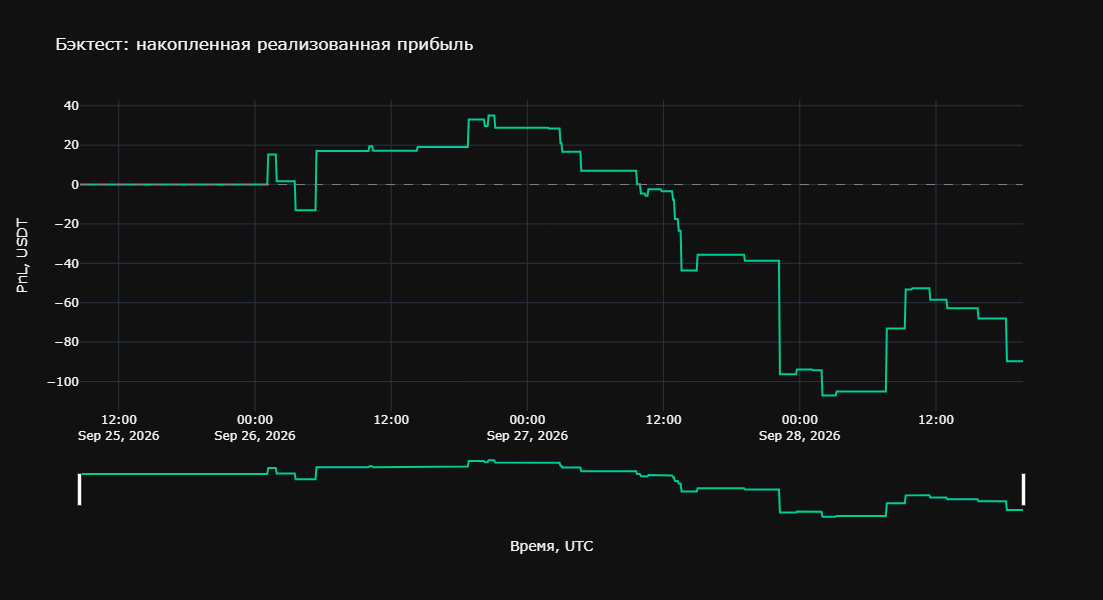

In [96]:
import plotly.graph_objects as go

equity = result.equity_curve.copy()

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=equity["datetime_utc"],
        y=equity["equity_usdt"],
        mode="lines",
        name="Накопленная прибыль",
        line=dict(
            color="#00CC96",
            width=2,
        ),
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Cumulative PnL: %{y:.2f} USDT"
            "<extra></extra>"
        ),
    )
)

fig.add_hline(
    y=0,
    line_color="gray",
    line_width=1,
    line_dash="dash",
)

fig.update_layout(
    title="Бэктест: накопленная реализованная прибыль",
    template="plotly_dark",
    height=600,
    dragmode="pan",
    hovermode="x unified",

    xaxis=dict(
        title="Время, UTC",
        rangeslider=dict(visible=True),
    ),

    yaxis=dict(
        title="PnL, USDT",
        zeroline=False,
    ),
)

fig.show(
    config={
        "scrollZoom": True,
        "displaylogo": False,
    }
)

In [73]:
from itertools import product

In [74]:
def optimize_zscore_parameters(
    data: pd.DataFrame,
    max_window: int = 300,
    min_window: int = 20,
    window_step: int = 5,

    long_entry_values: Optional[list[float]] = None,
    short_entry_values: Optional[list[float]] = None,

    exit_z: float = 0.0,
    stop_z: float = 4.0,

    gross_notional_usdt: float = 1_000,
    fee_bps_per_leg: float = 10.0,
    slippage_bps_per_leg: float = 5.0,

    min_trades: int = 5,
) -> pd.DataFrame:
    """
    Grid search по параметрам стратегии.

    Оптимизируемый параметр:
        net_profit_usdt

    Но в итоговой таблице остаются:
        - max_drawdown;
        - число сделок;
        - win rate;
        - profit factor;
        - средняя прибыль на сделку.

    min_trades нужен, чтобы не выбрать комбинацию
    с одной случайно удачной сделкой.
    """
    if long_entry_values is None:
        long_entry_values = [
            -1.0,
            -1.25,
            -1.5,
            -1.75,
            -2.0,
        ]

    if short_entry_values is None:
        short_entry_values = [
            1.0,
            1.25,
            1.5,
            1.75,
            2.0,
            2.5,
        ]

    if max_window >= len(data):
        max_window = len(data) - 1

    rows = []

    windows = range(
        min_window,
        max_window + 1,
        window_step,
    )

    for window, long_entry_z, short_entry_z in product(
        windows,
        long_entry_values,
        short_entry_values,
    ):
        try:
            result = backtest_zscore_strategy(
                data=data,
                window=window,

                long_entry_z=long_entry_z,
                short_entry_z=short_entry_z,

                exit_z=exit_z,
                stop_z=stop_z,

                gross_notional_usdt=gross_notional_usdt,
                fee_bps_per_leg=fee_bps_per_leg,
                slippage_bps_per_leg=slippage_bps_per_leg,
            )

            metrics = result.metrics.copy()

            if metrics["trade_count"] < min_trades:
                continue

            rows.append(metrics)

        except Exception as error:
            print(
                f"Пропуск: window={window}, "
                f"long={long_entry_z}, "
                f"short={short_entry_z}. "
                f"Ошибка: {error}"
            )

    results = pd.DataFrame(rows)

    if results.empty:
        raise RuntimeError(
            "Не найдено комбинаций с достаточным числом сделок. "
            "Уменьши min_trades, комиссии, пороги входа "
            "или увеличь объём исторических данных."
        )

    results = results.sort_values(
        by=[
            "net_profit_usdt",
            "profit_factor",
            "max_drawdown_usdt",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    ).reset_index(drop=True)

    return results

In [97]:
optimization = optimize_zscore_parameters(
    data=data,

    max_window=300,
    min_window=20,
    window_step=5,

    long_entry_values=[
        -1.0,
        -1.25,
        -1.5,
        -1.75,
        -2.0,
    ],

    short_entry_values=[
        1.0,
        1.25,
        1.5,
        1.75,
        2.0,
        2.5,
    ],

    exit_z=0.0,
    stop_z=4.0,

    gross_notional_usdt=100,

    fee_bps_per_leg=10.0,
    slippage_bps_per_leg=5.0,

    min_trades=5,
)

print(optimization.head(20).to_string(index=False))

 window  long_entry_z  short_entry_z  exit_z  stop_z  gross_notional_usdt  trade_count  net_profit_usdt  win_rate_percent  profit_factor  average_trade_pnl_usdt  median_trade_pnl_usdt  max_drawdown_usdt  average_holding_bars  max_holding_bars
    165          -2.0           1.75     0.0     4.0                 1000           29        83.889903         48.275862       1.972753                2.892755              -1.007122         -48.398374             10.310345                49
    155          -2.0           2.00     0.0     4.0                 1000           24        82.747324         54.166667       2.285057                3.447805               1.868605         -38.933222             11.041667                49
    155          -2.0           1.75     0.0     4.0                 1000           31        81.115900         51.612903       1.886406                2.616642               1.126818         -48.780488              9.516129                49
    155          -2.0       

In [79]:
best = optimization.iloc[0]

print(best)

#Запуск лучшей найденной комбинации:
best_result = backtest_zscore_strategy(
    data=data,

    window=int(best["window"]),

    long_entry_z=float(best["long_entry_z"]),
    short_entry_z=float(best["short_entry_z"]),

    exit_z=float(best["exit_z"]),
    stop_z=float(best["stop_z"]),

    gross_notional_usdt=float(best["gross_notional_usdt"]),

    fee_bps_per_leg=10.0,
    slippage_bps_per_leg=5.0,
)

print(pd.Series(best_result.metrics))

window                     180.000000
long_entry_z                -1.500000
short_entry_z                2.500000
exit_z                       0.000000
stop_z                       4.000000
gross_notional_usdt       1000.000000
trade_count                 12.000000
net_profit_usdt             54.089645
win_rate_percent            66.666667
profit_factor               10.499868
average_trade_pnl_usdt       4.507470
median_trade_pnl_usdt        3.750872
max_drawdown_usdt           -2.932314
average_holding_bars        29.583333
max_holding_bars           113.000000
Name: 0, dtype: float64
window                     180.000000
long_entry_z                -1.500000
short_entry_z                2.500000
exit_z                       0.000000
stop_z                       4.000000
gross_notional_usdt       1000.000000
trade_count                 12.000000
net_profit_usdt             54.089645
win_rate_percent            66.666667
profit_factor               10.499868
average_trade_pnl_usdt    

In [83]:
from __future__ import annotations

import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.graph_objects as go
import pandas as pd
import numpy as np

In [84]:
def interactive_spread_zscore_dashboard(
    data: pd.DataFrame,
    initial_window: int = 180,
    initial_long_entry_z: float = -1.5,
    initial_short_entry_z: float = 2.5,
    initial_exit_z: float = 0.0,
    initial_stop_z: float = 4.0,
    initial_gross_notional: float = 1_000.0,
    height_spread: int = 400,
    height_zscore: int = 400,
):
    """
    Интерактивная панель:

    - Верхний график: спред (close_a - close_b) с точками сделок.
    - Нижний график: Z-score с уровнями входа/выхода и точками сделок.
    - Ползунки: window, long_entry_z, short_entry_z, stop_z, gross_notional.
    """

    # Ограничения ползунков.
    max_window = min(len(data) - 1, 500)

    if max_window < 2:
        raise ValueError(
            "В data слишком мало строк для расчёта Z-score."
        )

    initial_window = min(initial_window, max_window)

    # Ползунки.
    window_slider = widgets.IntSlider(
        value=initial_window,
        min=2,
        max=max_window,
        step=1,
        description="Window:",
        continuous_update=False,
        style={"description_width": "initial"},
        layout=widgets.Layout(width="800px"),
    )

    long_entry_slider = widgets.FloatSlider(
        value=initial_long_entry_z,
        min=-4.0,
        max=0.0,
        step=0.25,
        description="Long entry σ:",
        continuous_update=False,
        style={"description_width": "initial"},
        layout=widgets.Layout(width="800px"),
    )

    short_entry_slider = widgets.FloatSlider(
        value=initial_short_entry_z,
        min=0.0,
        max=4.0,
        step=0.25,
        description="Short entry σ:",
        continuous_update=False,
        style={"description_width": "initial"},
        layout=widgets.Layout(width="800px"),
    )

    exit_z_slider = widgets.FloatSlider(
        value=initial_exit_z,
        min=-1.0,
        max=1.0,
        step=0.1,
        description="Exit σ:",
        continuous_update=False,
        style={"description_width": "initial"},
        layout=widgets.Layout(width="800px"),
    )

    stop_z_slider = widgets.FloatSlider(
        value=initial_stop_z,
        min=2.0,
        max=6.0,
        step=0.5,
        description="Stop σ:",
        continuous_update=False,
        style={"description_width": "initial"},
        layout=widgets.Layout(width="800px"),
    )

    gross_slider = widgets.FloatLogSlider(
        value=initial_gross_notional,
        base=10,
        min=2.0,   # 10^2 = 100
        max=4.0,   # 10^4 = 10 000
        step=0.1,
        description="Gross USDT:",
        continuous_update=False,
        style={"description_width": "initial"},
        layout=widgets.Layout(width="800px"),
    )

    info = widgets.HTML()

    output = widgets.Output()

    def update_dashboard(change=None):
        window = window_slider.value
        long_entry_z = long_entry_slider.value
        short_entry_z = short_entry_slider.value
        exit_z = exit_z_slider.value
        stop_z = stop_z_slider.value
        gross_notional = gross_slider.value

        # Базовая проверка.
        if long_entry_z >= exit_z:
            info.value = (
                "<b>Ошибка:</b> long_entry_z должен быть < exit_z. "
                "Скорректируй параметры."
            )
            return

        if short_entry_z <= exit_z:
            info.value = (
                "<b>Ошибка:</b> short_entry_z должен быть > exit_z. "
                "Скорректируй параметры."
            )
            return

        if stop_z <= max(abs(long_entry_z), abs(short_entry_z)):
            info.value = (
                "<b>Ошибка:</b> stop_z должен быть больше модулей entry-порогов."
            )
            return

        timeframe_minutes = 5
        hours = window * timeframe_minutes / 60

        info.value = (
            f"<b>Окно:</b> {window} свечей ≈ {hours:.2f} ч "
            f"({window * timeframe_minutes} минут)"
        )

        # -----------------------------------------------------
        # 1. Z-score и спред.
        # -----------------------------------------------------
        zscore_df = calculate_rolling_zscore(
            data=data,
            window=window,
        ).reset_index(drop=True)

        zscore_df = (
            zscore_df
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=["z_score"])
            .reset_index(drop=True)
        )

        if zscore_df.empty:
            with output:
                clear_output(wait=True)
                print(
                    "После расчёта Z-score не осталось данных. "
                    "Уменьши window или запроси больше свечей."
                )
            return

        # -----------------------------------------------------
        # 2. Бэктест для точек сделок.
        # -----------------------------------------------------
        try:
            result = backtest_zscore_strategy(
                data=zscore_df,
                window=window,
                long_entry_z=long_entry_z,
                short_entry_z=short_entry_z,
                exit_z=exit_z,
                stop_z=stop_z,
                gross_notional_usdt=gross_notional,
                fee_bps_per_leg=10.0,
                slippage_bps_per_leg=5.0,
            )
        except Exception as error:
            with output:
                clear_output(wait=True)
                print(f"Ошибка бэктеста: {error}")
            return

        trades = result.trades
        equity_df = result.equity_curve

        # -----------------------------------------------------
        # 3. Верхний график: спред + точки сделок.
        # -----------------------------------------------------
        spread_fig = go.Figure()

        spread_fig.add_trace(
            go.Scatter(
                x=zscore_df["datetime_utc"],
                y=zscore_df["spread"],
                mode="lines",
                name="Спред (A − B)",
                line=dict(
                    color="#00CC96",
                    width=1.5,
                ),
                hovertemplate=(
                    "<b>%{x}</b><br>"
                    "Спред: %{y:.10f} USDT"
                    "<extra></extra>"
                ),
            )
        )

        # Точки входа.
        if not trades.empty:
            long_entries = trades[
                trades["direction"] == "long_spread"
            ]
            short_entries = trades[
                trades["direction"] == "short_spread"
            ]

            if not long_entries.empty:
                spread_fig.add_trace(
                    go.Scatter(
                        x=long_entries["entry_time"],
                        y=long_entries["entry_price_a"] - long_entries["entry_price_b"],
                        mode="markers",
                        marker=dict(
                            symbol="triangle-up",
                            size=10,
                            color="#00FF00",
                            line=dict(
                                color="black",
                                width=1,
                            ),
                        ),
                        name="Вход: Long spread",
                        hovertemplate=(
                            "<b>Вход: Long spread</b><br>"
                            "Время: %{x}<br>"
                            "Спред: %{y:.10f} USDT"
                            "<extra></extra>"
                        ),
                    )
                )

            if not short_entries.empty:
                spread_fig.add_trace(
                    go.Scatter(
                        x=short_entries["entry_time"],
                        y=short_entries["entry_price_a"] - short_entries["entry_price_b"],
                        mode="markers",
                        marker=dict(
                            symbol="triangle-down",
                            size=10,
                            color="#FF0000",
                            line=dict(
                                color="black",
                                width=1,
                            ),
                        ),
                        name="Вход: Short spread",
                        hovertemplate=(
                            "<b>Вход: Short spread</b><br>"
                            "Время: %{x}<br>"
                            "Спред: %{y:.10f} USDT"
                            "<extra></extra>"
                        ),
                    )
                )

            # Точки выхода.
            exit_spreads = (
                trades["exit_price_a"] - trades["exit_price_b"]
            )

            spread_fig.add_trace(
                go.Scatter(
                    x=trades["exit_time"],
                    y=exit_spreads,
                    mode="markers",
                    marker=dict(
                        symbol="x",
                        size=8,
                        color="#FFFFFF",
                        line=dict(
                            color="black",
                            width=1,
                        ),
                    ),
                    name="Выход",
                    hovertemplate=(
                        "<b>Выход</b><br>"
                        "Время: %{x}<br>"
                        "Спред: %{y:.10f} USDT<br>"
                        "PnL: %{customdata[0]:.2f} USDT"
                        "<extra></extra>"
                    ),
                    customdata=trades[["net_pnl_usdt"]].to_numpy(),
                )
            )

        spread_fig.add_hline(
            y=0,
            line_color="gray",
            line_width=1,
            line_dash="dash",
        )

        spread_fig.update_layout(
            title="Абсолютный спред и сделки",
            template="plotly_dark",
            height=height_spread,
            dragmode="pan",
            hovermode="x unified",
            showlegend=True,
            margin=dict(l=70, r=30, t=70, b=40),
            xaxis=dict(
                title="Время, UTC",
                type="date",
                rangeslider=dict(visible=True),
            ),
            yaxis=dict(
                title="Спред, USDT",
                zeroline=False,
            ),
        )

        # -----------------------------------------------------
        # 4. Нижний график: Z-score + уровни + точки сделок.
        # -----------------------------------------------------
        zscore_fig = go.Figure()

        zscore_fig.add_trace(
            go.Scatter(
                x=zscore_df["datetime_utc"],
                y=zscore_df["z_score"],
                mode="lines",
                name="Z-score спреда",
                line=dict(
                    color="#00CC96",
                    width=1.5,
                ),
                hovertemplate=(
                    "<b>%{x}</b><br>"
                    "Z-score: %{y:.4f}"
                    "<extra></extra>"
                ),
            )
        )

        # Горизонтальные линии уровней.
        zscore_fig.add_hline(
            y=exit_z,
            line_color="white",
            line_width=1,
            line_dash="dash",
            annotation_text=f"Exit = {exit_z:.2f}σ",
            annotation_position="top left",
        )

        zscore_fig.add_hline(
            y=long_entry_z,
            line_color="#00FF00",
            line_width=1,
            line_dash="dot",
            annotation_text=f"Long entry = {long_entry_z:.2f}σ",
            annotation_position="bottom left",
        )

        zscore_fig.add_hline(
            y=short_entry_z,
            line_color="#FF0000",
            line_width=1,
            line_dash="dot",
            annotation_text=f"Short entry = {short_entry_z:.2f}σ",
            annotation_position="top left",
        )

        zscore_fig.add_hline(
            y=stop_z,
            line_color="#EF553B",
            line_width=1,
            line_dash="dash",
            annotation_text=f"+Stop = {stop_z:.2f}σ",
            annotation_position="top left",
        )

        zscore_fig.add_hline(
            y=-stop_z,
            line_color="#EF553B",
            line_width=1,
            line_dash="dash",
            annotation_text=f"−Stop = {-stop_z:.2f}σ",
            annotation_position="bottom left",
        )

        # Точки входа/выхода на Z-score.
        if not trades.empty:
            long_entries = trades[
                trades["direction"] == "long_spread"
            ]
            short_entries = trades[
                trades["direction"] == "short_spread"
            ]

            if not long_entries.empty:
                zscore_fig.add_trace(
                    go.Scatter(
                        x=long_entries["entry_time"],
                        y=long_entries["entry_z"],
                        mode="markers",
                        marker=dict(
                            symbol="triangle-up",
                            size=10,
                            color="#00FF00",
                            line=dict(
                                color="black",
                                width=1,
                            ),
                        ),
                        name="Вход: Long spread",
                        hovertemplate=(
                            "<b>Вход: Long spread</b><br>"
                            "Время: %{x}<br>"
                            "Z-score: %{y:.4f}"
                            "<extra></extra>"
                        ),
                    )
                )

            if not short_entries.empty:
                zscore_fig.add_trace(
                    go.Scatter(
                        x=short_entries["entry_time"],
                        y=short_entries["entry_z"],
                        mode="markers",
                        marker=dict(
                            symbol="triangle-down",
                            size=10,
                            color="#FF0000",
                            line=dict(
                                color="black",
                                width=1,
                            ),
                        ),
                        name="Вход: Short spread",
                        hovertemplate=(
                            "<b>Вход: Short spread</b><br>"
                            "Время: %{x}<br>"
                            "Z-score: %{y:.4f}"
                            "<extra></extra>"
                        ),
                    )
                )

            # Выходы.
            zscore_fig.add_trace(
                go.Scatter(
                    x=trades["exit_time"],
                    y=trades["exit_z"],
                    mode="markers",
                    marker=dict(
                        symbol="x",
                        size=8,
                        color="#FFFFFF",
                        line=dict(
                            color="black",
                            width=1,
                        ),
                    ),
                    name="Выход",
                    hovertemplate=(
                        "<b>Выход</b><br>"
                        "Время: %{x}<br>"
                        "Z-score: %{y:.4f}<br>"
                        "PnL: %{customdata[0]:.2f} USDT"
                        "<extra></extra>"
                    ),
                    customdata=trades[["net_pnl_usdt"]].to_numpy(),
                )
            )

        zscore_fig.add_hline(
            y=0,
            line_color="gray",
            line_width=1,
            line_dash="dash",
        )

        zscore_fig.update_layout(
            title="Z-score спреда с уровнями и сделками",
            template="plotly_dark",
            height=height_zscore,
            dragmode="pan",
            hovermode="x unified",
            showlegend=True,
            margin=dict(l=70, r=30, t=70, b=40),
            xaxis=dict(
                title="Время, UTC",
                type="date",
                rangeslider=dict(visible=True),
            ),
            yaxis=dict(
                title="Z-score",
                zeroline=False,
            ),
        )

        # -----------------------------------------------------
        # 5. Вывод.
        # -----------------------------------------------------
        with output:
            clear_output(wait=True)

            spread_fig.show(
                config={
                    "scrollZoom": True,
                    "displaylogo": False,
                    "responsive": True,
                }
            )

            zscore_fig.show(
                config={
                    "scrollZoom": True,
                    "displaylogo": False,
                    "responsive": True,
                }
            )

            print(
                f"Сделок: {len(trades)} | "
                f"Net PnL: {result.metrics['net_profit_usdt']:.2f} USDT | "
                f"Win rate: {result.metrics['win_rate_percent']:.1f}% | "
                f"PF: {result.metrics['profit_factor']:.2f}"
            )

    window_slider.observe(update_dashboard, names="value")
    long_entry_slider.observe(update_dashboard, names="value")
    short_entry_slider.observe(update_dashboard, names="value")
    exit_z_slider.observe(update_dashboard, names="value")
    stop_z_slider.observe(update_dashboard, names="value")
    gross_slider.observe(update_dashboard, names="value")

    controls = widgets.VBox([
        window_slider,
        long_entry_slider,
        short_entry_slider,
        exit_z_slider,
        stop_z_slider,
        gross_slider,
        info,
    ])

    display(controls, output)

    # Первая отрисовка.
    update_dashboard()

    return {
        "window_slider": window_slider,
        "long_entry_slider": long_entry_slider,
        "short_entry_slider": short_entry_slider,
        "exit_z_slider": exit_z_slider,
        "stop_z_slider": stop_z_slider,
        "gross_slider": gross_slider,
    }

In [98]:
dashboard = interactive_spread_zscore_dashboard(
    data=data,

    initial_window=180,
    initial_long_entry_z=-1.5,
    initial_short_entry_z=2.5,
    initial_exit_z=0.0,
    initial_stop_z=4.0,
    initial_gross_notional=1_000.0,

    height_spread=450,
    height_zscore=450,
)

Output()

# BDX/USDT Perpetual: MEXC vs KuCoin
- Таймфрейм: `5m`
- Рынок: `swap`
- Номинал позиции: `1,000 USDT`
- Комиссия на одну ногу: `10.0 bps`
- Проскальзывание на одну ногу: `5.0 bps`

## 1. Получение и синхронизация данных

MEXC: symbol=BDX/USDT:USDT, type=swap, spot=False, swap=True, future=False
KUCOIN: symbol=BDX/USDT:USDT, type=swap, spot=False, swap=True, future=False

Запрос A: mexc | BDX/USDT:USDT | swap | 5m
Запрос B: kucoin | BDX/USDT:USDT | swap | 5m
Синхронизированных свечей: 200
Начало истории: 2026-09-25 08:45:00+00:00
Конец истории:  2026-09-26 01:20:00+00:00


### Первые пять синхронизированных свечей

,timestamp,close_a,close_b,datetime_utc
0,1790325900000,0.0780,0.07744,2026-09-25 08:45:00+00:00
1,1790326200000,0.0778,0.07722,2026-09-25 08:50:00+00:00
2,1790326500000,0.0778,0.07778,2026-09-25 08:55:00+00:00
3,1790326800000,0.0779,0.07760,2026-09-25 09:00:00+00:00
4,1790327100000,0.0777,0.07747,2026-09-25 09:05:00+00:00


### Последние пять синхронизированных свечей

,timestamp,close_a,close_b,datetime_utc
195,1790384400000,0.0778,0.07645,2026-09-26 01:00:00+00:00
196,1790384700000,0.0780,0.07649,2026-09-26 01:05:00+00:00
197,1790385000000,0.0782,0.07663,2026-09-26 01:10:00+00:00
198,1790385300000,0.0777,0.07647,2026-09-26 01:15:00+00:00
199,1790385600000,0.0779,0.07637,2026-09-26 01:20:00+00:00


## 2. Абсолютный спред и Z-score
Начальное окно: `180` свечей = `15.00` часа.

### Статистика абсолютного спреда

,Значение
"Минимальный спред, USDT",0.001230
"Максимальный спред, USDT",0.002670
"Средний спред, USDT",0.001954
"Std спреда, USDT",0.000496


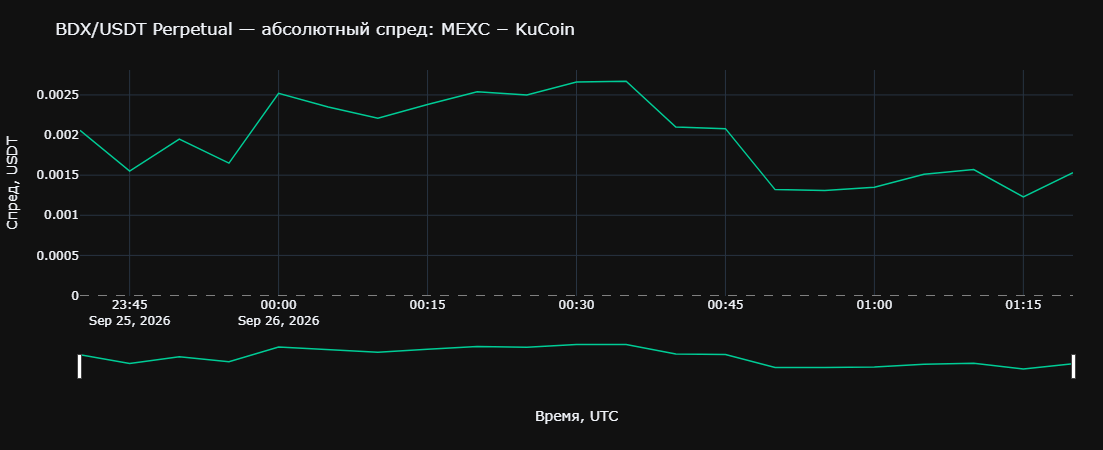

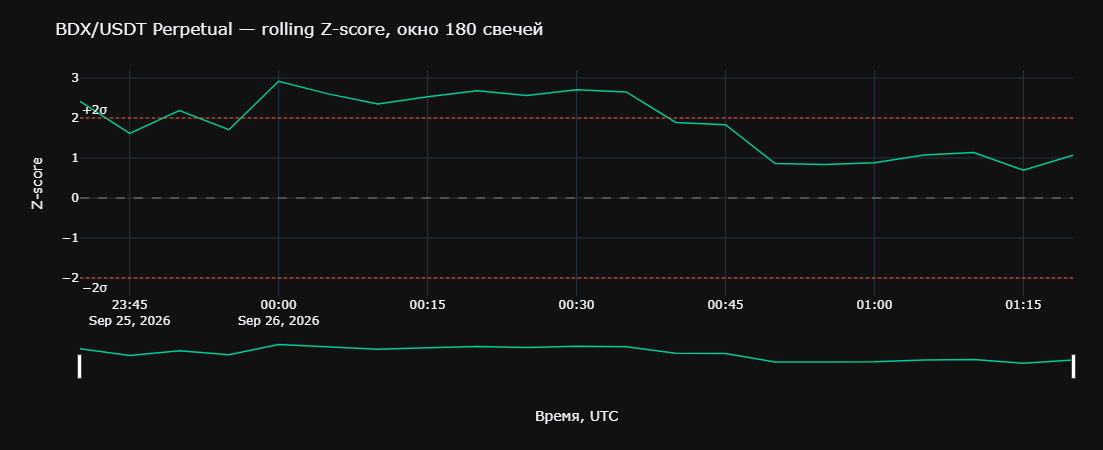

## 3. Grid search параметров стратегии
Перебираются размеры окна и пороги входа. Выводятся только конфигурации с минимум пятью закрытыми сделками.

### Топ-20 конфигураций по чистой прибыли

,window,long_entry_z,short_entry_z,exit_z,stop_z,gross_notional_usdt,trade_count,net_profit_usdt,win_rate_percent,profit_factor,average_trade_pnl_usdt,median_trade_pnl_usdt,max_drawdown_usdt,average_holding_bars,max_holding_bars
0,35,-1.50,2.50,0.0,4.0,1000.0,6,-2.345743,66.666667,0.722760,-0.390957,0.403308,-5.653529,10.000000,28
1,35,-1.75,2.50,0.0,4.0,1000.0,5,-2.645393,60.000000,0.687345,-0.529079,0.506965,-5.653529,11.400000,28
2,25,-2.00,2.00,0.0,4.0,1000.0,7,-2.813686,42.857143,0.711143,-0.401955,-0.175866,-7.625474,8.285714,24
3,40,-1.75,2.00,0.0,4.0,1000.0,7,-4.413970,42.857143,0.610797,-0.630567,-0.623714,-7.322265,9.000000,30
4,40,-2.00,2.00,0.0,4.0,1000.0,7,-4.413970,42.857143,0.610797,-0.630567,-0.623714,-7.322265,9.000000,30
5,35,-2.00,2.50,0.0,4.0,1000.0,5,-4.765139,40.000000,0.526978,-0.953028,-1.612780,-7.266310,11.000000,28
6,40,-1.75,2.50,0.0,4.0,1000.0,5,-4.765139,40.000000,0.526978,-0.953028,-1.612780,-7.266310,11.000000,28
7,40,-2.00,2.50,0.0,4.0,1000.0,5,-4.765139,40.000000,0.526978,-0.953028,-1.612780,-7.266310,11.000000,28
8,30,-1.50,2.50,0.0,4.0,1000.0,6,-4.903472,50.000000,0.483110,-0.817245,-0.063794,-9.059247,9.666667,24
9,25,-2.00,1.75,0.0,4.0,1000.0,7,-5.375990,42.857143,0.482212,-0.767999,-0.175866,-8.267322,9.285714,26


## 4. Лучшая найденная конфигурация

,Значение
window,35.000000
long_entry_z,-1.500000
short_entry_z,2.500000
exit_z,0.000000
stop_z,4.000000
gross_notional_usdt,1000.000000
trade_count,6.000000
net_profit_usdt,-2.345743
win_rate_percent,66.666667
profit_factor,0.722760


### Итоговые метрики лучшего бэктеста

,Значение
window,35.000000
long_entry_z,-1.500000
short_entry_z,2.500000
exit_z,0.000000
stop_z,4.000000
gross_notional_usdt,1000.000000
trade_count,6.000000
net_profit_usdt,-2.345743
win_rate_percent,66.666667
profit_factor,0.722760


## 5. Накопленный реализованный PnL
График учитывает только закрытые сделки. Плавающий PnL внутри открытой позиции пока не включён.

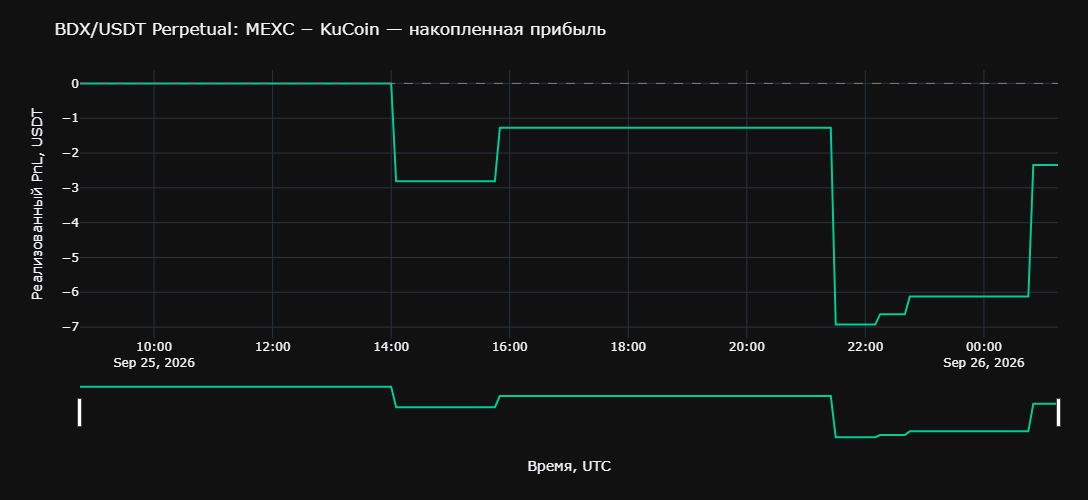

## 6. Интерактивный дашборд
Можно менять размер окна, пороги входа/выхода, стоп и номинал позиции. Графики пересчитываются на уже загруженной истории без нового API-запроса.

Output()

In [100]:
# ============================================================
# ОТЧЁТ: BDX/USDT PERPETUAL — MEXC vs KuCoin
# Используются уже объявленные ранее функции:
#
# get_synchronized_close_arrays(...)
# calculate_rolling_zscore(...)
# optimize_zscore_parameters(...)
# backtest_zscore_strategy(...)
# interactive_spread_zscore_dashboard(...)
# ============================================================

from IPython.display import display, Markdown
import numpy as np
import pandas as pd
import plotly.graph_objects as go


# ------------------------------------------------------------
# 1. ПАРАМЕТРЫ ИССЛЕДОВАНИЯ
# ------------------------------------------------------------

EXCHANGE_A = "mexc"
EXCHANGE_B = "kucoin"

TOKEN = "BDX"
QUOTE = "USDT"

MARKET_TYPE = "swap"
TIMEFRAME = "5m"
LIMIT = 1000

INITIAL_WINDOW = 180

FEE_BPS_PER_LEG = 10.0
SLIPPAGE_BPS_PER_LEG = 5.0
GROSS_NOTIONAL_USDT = 1_000.0

display(Markdown(
    "# BDX/USDT Perpetual: MEXC vs KuCoin\n"
    f"- Таймфрейм: `{TIMEFRAME}`\n"
    f"- Рынок: `{MARKET_TYPE}`\n"
    f"- Номинал позиции: `{GROSS_NOTIONAL_USDT:,.0f} USDT`\n"
    f"- Комиссия на одну ногу: `{FEE_BPS_PER_LEG:.1f} bps`\n"
    f"- Проскальзывание на одну ногу: `{SLIPPAGE_BPS_PER_LEG:.1f} bps`"
))


# ------------------------------------------------------------
# 2. ЗАГРУЗКА И СИНХРОНИЗАЦИЯ СВЕЧЕЙ
# ------------------------------------------------------------

display(Markdown("## 1. Получение и синхронизация данных"))

pairs_bdx, data_bdx = get_synchronized_close_arrays(
    exchange_a_id=EXCHANGE_A,
    token_a=TOKEN,
    exchange_b_id=EXCHANGE_B,
    token_b=TOKEN,
    timeframe=TIMEFRAME,
    limit=LIMIT,
    market_type=MARKET_TYPE,
)

data_bdx = data_bdx.copy()

print(f"Синхронизированных свечей: {len(data_bdx)}")
print(f"Начало истории: {data_bdx['datetime_utc'].iloc[0]}")
print(f"Конец истории:  {data_bdx['datetime_utc'].iloc[-1]}")

display(Markdown("### Первые пять синхронизированных свечей"))
display(data_bdx.head())

display(Markdown("### Последние пять синхронизированных свечей"))
display(data_bdx.tail())


# ------------------------------------------------------------
# 3. СПРЕД И Z-SCORE
# ------------------------------------------------------------

display(Markdown(
    f"## 2. Абсолютный спред и Z-score\n"
    f"Начальное окно: `{INITIAL_WINDOW}` свечей "
    f"= `{INITIAL_WINDOW * 5 / 60:.2f}` часа."
))

zscore_bdx = calculate_rolling_zscore(
    data=data_bdx,
    window=INITIAL_WINDOW,
)

zscore_bdx = (
    zscore_bdx
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["z_score"])
    .reset_index(drop=True)
)

spread_stats = zscore_bdx["spread"].agg([
    "min",
    "max",
    "mean",
    "std",
]).rename({
    "min": "Минимальный спред, USDT",
    "max": "Максимальный спред, USDT",
    "mean": "Средний спред, USDT",
    "std": "Std спреда, USDT",
})

display(Markdown("### Статистика абсолютного спреда"))
display(spread_stats.to_frame(name="Значение"))


# ---- График 1: Абсолютный спред ----

spread_fig = go.Figure()

spread_fig.add_trace(
    go.Scatter(
        x=zscore_bdx["datetime_utc"],
        y=zscore_bdx["spread"],
        mode="lines",
        name="Спред MEXC − KuCoin",
        line=dict(
            color="#00CC96",
            width=1.5,
        ),
        customdata=zscore_bdx[
            ["close_a", "close_b", "z_score"]
        ].to_numpy(),
        hovertemplate=(
            "<b>Время: %{x}</b><br>"
            "Спред: %{y:.10f} USDT<br>"
            "MEXC close: %{customdata[0]:.10f}<br>"
            "KuCoin close: %{customdata[1]:.10f}<br>"
            "Z-score: %{customdata[2]:.4f}"
            "<extra></extra>"
        ),
    )
)

spread_fig.add_hline(
    y=0,
    line_color="gray",
    line_width=1,
    line_dash="dash",
)

spread_fig.update_layout(
    title="BDX/USDT Perpetual — абсолютный спред: MEXC − KuCoin",
    template="plotly_dark",
    height=450,
    dragmode="pan",
    hovermode="x unified",
    margin=dict(l=80, r=30, t=70, b=60),

    xaxis=dict(
        title="Время, UTC",
        type="date",
        rangeslider=dict(visible=True),
    ),

    yaxis=dict(
        title="Спред, USDT",
        zeroline=False,
    ),
)

spread_fig.show(
    config={
        "scrollZoom": True,
        "displaylogo": False,
        "responsive": True,
    }
)


# ---- График 2: Z-score ----

zscore_fig = go.Figure()

zscore_fig.add_trace(
    go.Scatter(
        x=zscore_bdx["datetime_utc"],
        y=zscore_bdx["z_score"],
        mode="lines",
        name="Rolling Z-score",
        line=dict(
            color="#00CC96",
            width=1.5,
        ),
        hovertemplate=(
            "<b>Время: %{x}</b><br>"
            "Z-score: %{y:.4f}"
            "<extra></extra>"
        ),
    )
)

zscore_fig.add_hline(
    y=0,
    line_color="gray",
    line_width=1,
    line_dash="dash",
)

zscore_fig.add_hline(
    y=2,
    line_color="#EF553B",
    line_width=1,
    line_dash="dot",
    annotation_text="+2σ",
    annotation_position="top left",
)

zscore_fig.add_hline(
    y=-2,
    line_color="#EF553B",
    line_width=1,
    line_dash="dot",
    annotation_text="−2σ",
    annotation_position="bottom left",
)

zscore_fig.update_layout(
    title=f"BDX/USDT Perpetual — rolling Z-score, окно {INITIAL_WINDOW} свечей",
    template="plotly_dark",
    height=450,
    dragmode="pan",
    hovermode="x unified",
    margin=dict(l=80, r=30, t=70, b=60),

    xaxis=dict(
        title="Время, UTC",
        type="date",
        rangeslider=dict(visible=True),
    ),

    yaxis=dict(
        title="Z-score",
        zeroline=False,
    ),
)

zscore_fig.show(
    config={
        "scrollZoom": True,
        "displaylogo": False,
        "responsive": True,
    }
)


# ------------------------------------------------------------
# 4. GRID SEARCH: ПОДБОР ПАРАМЕТРОВ
# ------------------------------------------------------------

display(Markdown(
    "## 3. Grid search параметров стратегии\n"
    "Перебираются размеры окна и пороги входа. "
    "Выводятся только конфигурации с минимум пятью закрытыми сделками."
))

optimization_bdx = optimize_zscore_parameters(
    data=data_bdx,

    min_window=20,
    max_window=min(300, len(data_bdx) - 1),
    window_step=5,

    long_entry_values=[
        -1.0,
        -1.25,
        -1.5,
        -1.75,
        -2.0,
    ],

    short_entry_values=[
        1.0,
        1.25,
        1.5,
        1.75,
        2.0,
        2.5,
    ],

    exit_z=0.0,
    stop_z=4.0,

    gross_notional_usdt=GROSS_NOTIONAL_USDT,

    fee_bps_per_leg=FEE_BPS_PER_LEG,
    slippage_bps_per_leg=SLIPPAGE_BPS_PER_LEG,

    min_trades=5,
)

display(Markdown("### Топ-20 конфигураций по чистой прибыли"))
display(optimization_bdx.head(20))


# ------------------------------------------------------------
# 5. ЛУЧШАЯ КОНФИГУРАЦИЯ
# ------------------------------------------------------------

best_bdx = optimization_bdx.iloc[0].copy()

display(Markdown("## 4. Лучшая найденная конфигурация"))
display(best_bdx.to_frame(name="Значение"))

best_result_bdx = backtest_zscore_strategy(
    data=data_bdx,

    window=int(best_bdx["window"]),

    long_entry_z=float(best_bdx["long_entry_z"]),
    short_entry_z=float(best_bdx["short_entry_z"]),

    exit_z=float(best_bdx["exit_z"]),
    stop_z=float(best_bdx["stop_z"]),

    gross_notional_usdt=GROSS_NOTIONAL_USDT,

    fee_bps_per_leg=FEE_BPS_PER_LEG,
    slippage_bps_per_leg=SLIPPAGE_BPS_PER_LEG,
)

best_metrics_bdx = pd.Series(best_result_bdx.metrics).rename("Значение")

display(Markdown("### Итоговые метрики лучшего бэктеста"))
display(best_metrics_bdx.to_frame())


# ------------------------------------------------------------
# 6. ГРАФИК НАКОПЛЕННОГО PNL
# ------------------------------------------------------------

display(Markdown(
    "## 5. Накопленный реализованный PnL\n"
    "График учитывает только закрытые сделки. "
    "Плавающий PnL внутри открытой позиции пока не включён."
))

equity_bdx = best_result_bdx.equity_curve.copy()

pnl_fig = go.Figure()

pnl_fig.add_trace(
    go.Scatter(
        x=equity_bdx["datetime_utc"],
        y=equity_bdx["equity_usdt"],
        mode="lines",
        name="Накопленный реализованный PnL",
        line=dict(
            color="#00CC96",
            width=2,
        ),
        hovertemplate=(
            "<b>Время: %{x}</b><br>"
            "Накопленный PnL: %{y:.2f} USDT"
            "<extra></extra>"
        ),
    )
)

pnl_fig.add_hline(
    y=0,
    line_color="gray",
    line_width=1,
    line_dash="dash",
)

pnl_fig.update_layout(
    title="BDX/USDT Perpetual: MEXC − KuCoin — накопленная прибыль",
    template="plotly_dark",
    height=500,
    dragmode="pan",
    hovermode="x unified",
    margin=dict(l=80, r=30, t=70, b=60),

    xaxis=dict(
        title="Время, UTC",
        type="date",
        rangeslider=dict(visible=True),
    ),

    yaxis=dict(
        title="Реализованный PnL, USDT",
        zeroline=False,
    ),
)

pnl_fig.show(
    config={
        "scrollZoom": True,
        "displaylogo": False,
        "responsive": True,
    }
)


# ------------------------------------------------------------
# 7. ИНТЕРАКТИВНЫЙ ДАШБОРД
# ------------------------------------------------------------

display(Markdown(
    "## 6. Интерактивный дашборд\n"
    "Можно менять размер окна, пороги входа/выхода, стоп и номинал позиции. "
    "Графики пересчитываются на уже загруженной истории без нового API-запроса."
))

dashboard_bdx = interactive_spread_zscore_dashboard(
    data=data_bdx,

    initial_window=int(best_bdx["window"]),
    initial_long_entry_z=float(best_bdx["long_entry_z"]),
    initial_short_entry_z=float(best_bdx["short_entry_z"]),

    initial_exit_z=float(best_bdx["exit_z"]),
    initial_stop_z=float(best_bdx["stop_z"]),

    initial_gross_notional=GROSS_NOTIONAL_USDT,

    height_spread=450,
    height_zscore=450,
)

In [1]:
#ОТЧЁТ И БЭКТЕСТ
# BDX/USDT PERPETUAL: MEXC vs KUCOIN
#
# Один блок: функции + загрузка + графики + оптимизация +
# лучший бэктест + интерактивный dashboard.
# ============================================================

from __future__ import annotations

from dataclasses import dataclass
from itertools import product
from typing import Optional

import ccxt
import numpy as np
import pandas as pd
import plotly.graph_objects as go

import ipywidgets as widgets

from IPython.display import (
    Markdown,
    clear_output,
    display,
)


# ============================================================
# 1. НАСТРОЙКИ ЗАПУСКА
# ============================================================

# Биржи.
EXCHANGE_A_ID = "gate"
EXCHANGE_B_ID = "aster"

# Токен и рынок.
TOKEN_A = "ONE"
TOKEN_B = "ONE"

QUOTE = "USDT"
MARKET_TYPE = "swap"

# Свечи.
TIMEFRAME = "5m"
LIMIT = 1000

# Базовые параметры первого Z-score-графика.
INITIAL_WINDOW = 180

# Модель проскальзывания.
# CCXT может отдать комиссию, но не реальное проскальзывание.
SLIPPAGE_BPS_PER_LEG = 5.0

# Номинал позиции:
# 1 000 USDT = 500 USDT на MEXC + 500 USDT на KuCoin.
GROSS_NOTIONAL_USDT = 1_000.0

# Grid search.
MIN_WINDOW = 20
MAX_WINDOW = 300
WINDOW_STEP = 5

LONG_ENTRY_VALUES = [
-1.0,
-1.25,
-1.5,
-1.75,
-2.0,
]

SHORT_ENTRY_VALUES = [
1.0,
1.25,
1.5,
1.75,
2.0,
2.5,
]

EXIT_Z = 0.0
STOP_Z = 4.0
MIN_TRADES = 5

# Высота статичных графиков.
SPREAD_CHART_HEIGHT = 450
ZSCORE_CHART_HEIGHT = 450
PNL_CHART_HEIGHT = 500

# Показывать интерактивный dashboard в конце.
SHOW_DASHBOARD = True


In [17]:
# ============================================================
# ПО

# ============================================================
# 2. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ДЛЯ БИРЖ
# ============================================================

def normalize_exchange_id(
    exchange_id: str,
    market_type: str,
) -> str:
    """
    Исправляет типичный случай KuCoin.

    Для perpetual swap в CCXT используется отдельная реализация:
    kucoinfutures, а не обычная spot-биржа kucoin.
    """
    exchange_id = exchange_id.lower().strip()
    market_type = market_type.lower().strip()

    if exchange_id == "kucoin" and market_type in {"swap", "future"}:
        return "kucoinfutures"

    return exchange_id


def make_exchange(
    exchange_id: str,
    market_type: str = "spot",
) -> ccxt.Exchange:
    """
    Создаёт объект CCXT-биржи.

    market_type:
        spot   — спотовый рынок;
        swap   — perpetual / бессрочный фьючерс;
        future — фьючерс с экспирацией.
    """
    exchange_id = normalize_exchange_id(
        exchange_id=exchange_id,
        market_type=market_type,
    )

    market_type = market_type.lower().strip()

    allowed_market_types = {
        "spot",
        "swap",
        "future",
    }

    if market_type not in allowed_market_types:
        raise ValueError(
            f"Неизвестный market_type='{market_type}'. "
            f"Допустимо: {sorted(allowed_market_types)}"
        )

    if exchange_id not in ccxt.exchanges:
        raise ValueError(
            f"Биржа '{exchange_id}' не найдена в CCXT.\n"
            f"Примеры: mexc, gate, bybit, okx, "
            f"kucoin, kucoinfutures."
        )

    exchange_class = getattr(
        ccxt,
        exchange_id,
    )

    exchange = exchange_class({
        "enableRateLimit": True,
        "timeout": 30_000,
        "options": {
            "defaultType": market_type,
        },
    })

    if not exchange.has.get("fetchOHLCV"):
        raise RuntimeError(
            f"Биржа '{exchange_id}' не поддерживает fetchOHLCV."
        )

    exchange.load_markets()

    return exchange


def resolve_symbol(
    exchange: ccxt.Exchange,
    token: str,
    quote: str = "USDT",
    market_type: str = "spot",
) -> str:
    """
    Находит подходящий CCXT-symbol.

    Примеры:
        token='BDX', market_type='spot'
        -> BDX/USDT

        token='BDX', market_type='swap'
        -> BDX/USDT:USDT

    Можно передать полный symbol вручную:
        token='BDX/USDT:USDT'
    """
    token = token.upper().strip()
    quote = quote.upper().strip()
    market_type = market_type.lower().strip()

    # Полный CCXT-symbol задан вручную.
    if "/" in token:
        symbol = token

        if symbol not in exchange.markets:
            raise ValueError(
                f"На {exchange.id} не найден symbol '{symbol}'."
            )

        market = exchange.market(symbol)

        if market.get("type") != market_type:
            raise ValueError(
                f"{exchange.id}: symbol '{symbol}' имеет тип "
                f"'{market.get('type')}', но был запрошен "
                f"market_type='{market_type}'."
            )

        return symbol

    candidates = []

    for market in exchange.markets.values():
        if (
            market.get("base") == token
            and market.get("quote") == quote
            and market.get("type") == market_type
            and market.get("active", True)
        ):
            candidates.append(market)

    if not candidates:
        raise ValueError(
            f"На {exchange.id} не найден активный "
            f"{market_type}-рынок для {token}/{quote}."
        )

    # Для perpetual обычно остаётся ровно один кандидат.
    # Для dated futures может быть несколько контрактов.
    if market_type == "future" and len(candidates) > 1:
        available = [
            market["symbol"]
            for market in candidates
        ]

        raise ValueError(
            f"На {exchange.id} найдено несколько futures-контрактов "
            f"для {token}/{quote}:\n{available}\n\n"
            f"Передай нужный контракт полностью, например:\n"
            f"token_a='{available[0]}'"
        )

    market = candidates[0]

    print(
        f"{exchange.id.upper()} | "
        f"symbol={market['symbol']} | "
        f"type={market['type']} | "
        f"spot={market.get('spot')} | "
        f"swap={market.get('swap')} | "
        f"future={market.get('future')}"
    )

    return market["symbol"]


def get_taker_fee_rate(
    exchange: ccxt.Exchange,
    symbol: str,
) -> tuple[float, str]:
    """
    Возвращает taker fee в долях единицы.

    Пример:
        0.0006 = 0.06%
        0.0010 = 0.10%

    Порядок источников:
    1. fetch_trading_fee(symbol);
    2. market['taker'];
    3. exchange.fees['trading']['taker'].

    Если нет API-ключей, ставка обычно является публичной /
    стандартной ставкой, а не обязательно VIP-комиссией аккаунта.
    """
    market = exchange.market(symbol)

    # 1. Попытка получить ставку по конкретному рынку.
    if exchange.has.get("fetchTradingFee"):
        try:
            fee_info = exchange.fetch_trading_fee(symbol)

            taker_fee = fee_info.get("taker")

            if taker_fee is not None:
                return (
                    float(taker_fee),
                    "fetch_trading_fee",
                )

        except Exception as error:
            print(
                f"Предупреждение: {exchange.id} не вернула "
                f"fetch_trading_fee для {symbol}. "
                f"{type(error).__name__}: {error}"
            )

    # 2. Ставка в описании конкретного market.
    market_taker = market.get("taker")

    if market_taker is not None:
        return (
            float(market_taker),
            "market['taker']",
        )

    # 3. Общая дефолтная ставка биржи.
    exchange_taker = (
        exchange.fees
        .get("trading", {})
        .get("taker")
    )

    if exchange_taker is not None:
        return (
            float(exchange_taker),
            "exchange.fees['trading']['taker']",
        )

    raise RuntimeError(
        f"Не удалось определить taker-комиссию: "
        f"{exchange.id} | {symbol}."
    )


def fetch_close_prices(
    exchange: ccxt.Exchange,
    symbol: str,
    timeframe: str,
    limit: int,
    since: Optional[int] = None,
    only_closed: bool = True,
) -> pd.DataFrame:
    """
    Загружает OHLCV и возвращает:

        timestamp | close

    При only_closed=True удаляет незавершённую текущую свечу.
    """
    ohlcv = exchange.fetch_ohlcv(
        symbol=symbol,
        timeframe=timeframe,
        since=since,
        limit=limit,
    )

    if not ohlcv:
        raise RuntimeError(
            f"{exchange.id}: API не вернул свечи для "
            f"{symbol}, timeframe={timeframe}."
        )

    df = pd.DataFrame(
        ohlcv,
        columns=[
            "timestamp",
            "open",
            "high",
            "low",
            "close",
            "volume",
        ],
    )

    if only_closed:
        timeframe_ms = (
            exchange.parse_timeframe(timeframe)
            * 1000
        )

        now_ms = exchange.milliseconds()

        # timestamp — время начала свечи.
        # Оставляем только свечи, которые уже завершились.
        df = df[
            df["timestamp"] + timeframe_ms <= now_ms
        ].copy()

    df = (
        df[["timestamp", "close"]]
        .drop_duplicates(
            subset="timestamp",
            keep="last",
        )
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    return df


def get_synchronized_close_arrays(
    exchange_a_id: str,
    token_a: str,
    exchange_b_id: str,
    token_b: str,
    timeframe: str = "5m",
    limit: int = 500,
    quote: str = "USDT",
    market_type: str = "spot",
    since: Optional[int] = None,
    only_closed: bool = True,
) -> tuple[list[tuple[float, float]], pd.DataFrame]:
    """
    Загружает и синхронизирует свечи двух бирж.

    Возвращает:
        pairs:
            [(close_a_0, close_b_0), ...]

        synced_df:
            timestamp
            close_a
            close_b
            datetime_utc
            taker_fee_rate_a
            taker_fee_rate_b
            taker_fee_bps_a
            taker_fee_bps_b
    """
    market_type = market_type.lower().strip()

    exchange_a = make_exchange(
        exchange_id=exchange_a_id,
        market_type=market_type,
    )

    exchange_b = make_exchange(
        exchange_id=exchange_b_id,
        market_type=market_type,
    )

    symbol_a = resolve_symbol(
        exchange=exchange_a,
        token=token_a,
        quote=quote,
        market_type=market_type,
    )

    symbol_b = resolve_symbol(
        exchange=exchange_b,
        token=token_b,
        quote=quote,
        market_type=market_type,
    )

    fee_rate_a, fee_source_a = get_taker_fee_rate(
        exchange=exchange_a,
        symbol=symbol_a,
    )

    fee_rate_b, fee_source_b = get_taker_fee_rate(
        exchange=exchange_b,
        symbol=symbol_b,
    )

    print("\n" + "=" * 70)
    print("ПАРАМЕТРЫ ЗАГРУЗКИ")
    print("=" * 70)

    print(
        f"A: {exchange_a.id} | "
        f"{symbol_a} | "
        f"{market_type} | "
        f"{timeframe}"
    )

    print(
        f"B: {exchange_b.id} | "
        f"{symbol_b} | "
        f"{market_type} | "
        f"{timeframe}"
    )

    print(
        f"\nTaker fee A ({exchange_a.id}): "
        f"{fee_rate_a * 100:.5f}% | "
        f"{fee_rate_a * 10_000:.2f} bps | "
        f"источник: {fee_source_a}"
    )

    print(
        f"Taker fee B ({exchange_b.id}): "
        f"{fee_rate_b * 100:.5f}% | "
        f"{fee_rate_b * 10_000:.2f} bps | "
        f"источник: {fee_source_b}"
    )

    candles_a = fetch_close_prices(
        exchange=exchange_a,
        symbol=symbol_a,
        timeframe=timeframe,
        limit=limit,
        since=since,
        only_closed=only_closed,
    )

    candles_b = fetch_close_prices(
        exchange=exchange_b,
        symbol=symbol_b,
        timeframe=timeframe,
        limit=limit,
        since=since,
        only_closed=only_closed,
    )

    candles_a = candles_a.rename(
        columns={
            "close": "close_a",
        }
    )

    candles_b = candles_b.rename(
        columns={
            "close": "close_b",
        }
    )

    # Оставляет только timestamps, которые есть у обеих бирж.
    synced_df = candles_a.merge(
        candles_b,
        on="timestamp",
        how="inner",
        validate="one_to_one",
    )

    synced_df = (
        synced_df
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    synced_df["datetime_utc"] = pd.to_datetime(
        synced_df["timestamp"],
        unit="ms",
        utc=True,
    )

    # Комиссии сохраняем КОЛОНКАМИ.
    # Они не потеряются при copy(), slicing и rolling-расчётах.
    synced_df["taker_fee_rate_a"] = fee_rate_a
    synced_df["taker_fee_rate_b"] = fee_rate_b

    synced_df["taker_fee_bps_a"] = fee_rate_a * 10_000
    synced_df["taker_fee_bps_b"] = fee_rate_b * 10_000

    # Метаданные.
    synced_df.attrs["exchange_a"] = exchange_a.id
    synced_df.attrs["exchange_b"] = exchange_b.id

    synced_df.attrs["symbol_a"] = symbol_a
    synced_df.attrs["symbol_b"] = symbol_b

    synced_df.attrs["market_type"] = market_type
    synced_df.attrs["timeframe"] = timeframe

    synced_df.attrs["fee_source_a"] = fee_source_a
    synced_df.attrs["fee_source_b"] = fee_source_b

    close_prices_a = synced_df["close_a"].to_list()
    close_prices_b = synced_df["close_b"].to_list()

    pairs = list(
        zip(
            close_prices_a,
            close_prices_b,
        )
    )

    if synced_df.empty:
        raise RuntimeError(
            "После синхронизации не осталось общих timestamps. "
            "Проверь рынок, timeframe и доступность контракта "
            "на обеих биржах."
        )

    return pairs, synced_df


# ============================================================
# 3. Z-SCORE
# ============================================================

def calculate_rolling_zscore(
    data: pd.DataFrame,
    window: int,
) -> pd.DataFrame:
    """
    Рассчитывает абсолютный спред и rolling Z-score.

    spread = close_a - close_b

    Z-score:
        (spread - rolling_mean) / rolling_std
    """
    if window < 2:
        raise ValueError(
            "window должен быть не меньше 2."
        )

    required_columns = {
        "timestamp",
        "datetime_utc",
        "close_a",
        "close_b",
    }

    missing = required_columns - set(data.columns)

    if missing:
        raise ValueError(
            f"В data нет обязательных колонок: {missing}"
        )

    result = data.copy()

    result["spread"] = (
        result["close_a"] - result["close_b"]
    )

    result["spread_mean"] = (
        result["spread"]
        .rolling(
            window=window,
            min_periods=window,
        )
        .mean()
    )

    result["spread_std"] = (
        result["spread"]
        .rolling(
            window=window,
            min_periods=window,
        )
        .std(ddof=0)
    )

    result["z_score"] = (
        (result["spread"] - result["spread_mean"])
        / result["spread_std"]
    )

    result = result.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    return result


# ============================================================
# 4. БЭКТЕСТ
# ============================================================

@dataclass
class BacktestResult:
    trades: pd.DataFrame
    equity_curve: pd.DataFrame
    metrics: dict


def backtest_zscore_strategy(
    data: pd.DataFrame,
    window: int,
    long_entry_z: float = -1.5,
    short_entry_z: float = 2.0,
    exit_z: float = 0.0,
    stop_z: float = 4.0,
    gross_notional_usdt: float = 1_000.0,
    slippage_bps_per_leg: float = 5.0,
) -> BacktestResult:
    """
    Бэктест стратегии возврата межбиржевого спреда к среднему.

    Long spread:
        Z <= long_entry_z
        LONG A + SHORT B

    Short spread:
        Z >= short_entry_z
        SHORT A + LONG B

    Exit:
        long spread закрывается при Z >= exit_z;
        short spread закрывается при Z <= exit_z.

    Stop:
        long spread закрывается при Z <= -stop_z;
        short spread закрывается при Z >= +stop_z.

    Важная защита от look-ahead bias:
        Сигнал рассчитывается на свече t,
        исполнение моделируется на следующей свече t + 1.

    Комиссии:
        Берутся из taker_fee_rate_a / taker_fee_rate_b,
        сохранённых в data при загрузке через CCXT.

    PnL:
        Долларово-нейтральная позиция:
        gross_notional_usdt / 2 на каждую ногу.
    """
    if long_entry_z >= exit_z:
        raise ValueError(
            "long_entry_z должен быть меньше exit_z. "
            "Пример: -1.5 и 0.0."
        )

    if short_entry_z <= exit_z:
        raise ValueError(
            "short_entry_z должен быть больше exit_z. "
            "Пример: 2.0 и 0.0."
        )

    if stop_z <= max(
        abs(long_entry_z),
        abs(short_entry_z),
    ):
        raise ValueError(
            "stop_z должен быть больше модулей порогов входа."
        )

    if gross_notional_usdt <= 0:
        raise ValueError(
            "gross_notional_usdt должен быть больше нуля."
        )

    df = calculate_rolling_zscore(
        data=data,
        window=window,
    ).reset_index(drop=True)

    required_fee_columns = {
        "taker_fee_rate_a",
        "taker_fee_rate_b",
    }

    missing_fee_columns = (
        required_fee_columns
        - set(df.columns)
    )

    if missing_fee_columns:
        raise ValueError(
            "Нет колонок с CCXT-комиссиями: "
            f"{missing_fee_columns}. "
            "Заново получи data через "
            "get_synchronized_close_arrays(...)."
        )

    fee_rate_a = float(
        df["taker_fee_rate_a"].iloc[0]
    )

    fee_rate_b = float(
        df["taker_fee_rate_b"].iloc[0]
    )

    if fee_rate_a < 0 or fee_rate_b < 0:
        raise ValueError(
            "Комиссия не может быть отрицательной."
        )

    slippage_rate = (
        slippage_bps_per_leg / 10_000
    )

    # Общий nominal делится на две равные ноги.
    leg_notional = (
        gross_notional_usdt / 2
    )

    # Вход: две ноги.
    entry_cost = (
        leg_notional * (fee_rate_a + slippage_rate)
        + leg_notional * (fee_rate_b + slippage_rate)
    )

    # Выход: ещё две ноги.
    exit_cost = (
        leg_notional * (fee_rate_a + slippage_rate)
        + leg_notional * (fee_rate_b + slippage_rate)
    )

    full_round_trip_cost = (
        entry_cost + exit_cost
    )

    position: Optional[str] = None

    entry_index: Optional[int] = None
    entry_time = None

    entry_z = None
    entry_price_a = None
    entry_price_b = None

    quantity_a = None
    quantity_b = None

    realized_pnl = 0.0

    trades = []
    equity_rows = []

    # Нужна следующая свеча для исполнения.
    for i in range(len(df) - 1):
        signal_row = df.iloc[i]
        fill_row = df.iloc[i + 1]

        signal_time = signal_row["datetime_utc"]
        signal_z = signal_row["z_score"]

        fill_time = fill_row["datetime_utc"]
        fill_price_a = float(fill_row["close_a"])
        fill_price_b = float(fill_row["close_b"])

        # Пока rolling-window не набран.
        if pd.isna(signal_z):
            equity_rows.append({
                "timestamp": signal_row["timestamp"],
                "datetime_utc": signal_time,
                "z_score": signal_z,
                "position": position or "flat",
                "realized_pnl_usdt": realized_pnl,
                "equity_usdt": realized_pnl,
            })
            continue

        # ----------------------------------------------------
        # ОТКРЫТИЕ
        # ----------------------------------------------------
        if position is None:

            # LONG SPREAD:
            # long A, short B.
            if signal_z <= long_entry_z:
                position = "long_spread"

                entry_index = i + 1
                entry_time = fill_time

                entry_z = float(signal_z)
                entry_price_a = fill_price_a
                entry_price_b = fill_price_b

                quantity_a = (
                    leg_notional / entry_price_a
                )

                quantity_b = (
                    leg_notional / entry_price_b
                )

            # SHORT SPREAD:
            # short A, long B.
            elif signal_z >= short_entry_z:
                position = "short_spread"

                entry_index = i + 1
                entry_time = fill_time

                entry_z = float(signal_z)
                entry_price_a = fill_price_a
                entry_price_b = fill_price_b

                quantity_a = (
                    leg_notional / entry_price_a
                )

                quantity_b = (
                    leg_notional / entry_price_b
                )

        # ----------------------------------------------------
        # ЗАКРЫТИЕ
        # ----------------------------------------------------
        else:
            exit_reason = None

            if position == "long_spread":
                if signal_z >= exit_z:
                    exit_reason = "mean_reversion"

                elif signal_z <= -abs(stop_z):
                    exit_reason = "stop_z"

            elif position == "short_spread":
                if signal_z <= exit_z:
                    exit_reason = "mean_reversion"

                elif signal_z >= abs(stop_z):
                    exit_reason = "stop_z"

            if exit_reason is not None:
                exit_price_a = fill_price_a
                exit_price_b = fill_price_b

                # LONG A + SHORT B.
                if position == "long_spread":
                    gross_pnl = (
                        quantity_a
                        * (exit_price_a - entry_price_a)
                        + quantity_b
                        * (entry_price_b - exit_price_b)
                    )

                # SHORT A + LONG B.
                else:
                    gross_pnl = (
                        quantity_a
                        * (entry_price_a - exit_price_a)
                        + quantity_b
                        * (exit_price_b - entry_price_b)
                    )

                net_pnl = (
                    gross_pnl
                    - entry_cost
                    - exit_cost
                )

                realized_pnl += net_pnl

                holding_bars = (
                    (i + 1) - entry_index
                )

                trades.append({
                    "direction": position,

                    "entry_time": entry_time,
                    "exit_time": fill_time,

                    "entry_index": entry_index,
                    "exit_index": i + 1,

                    "entry_z": entry_z,
                    "exit_z": float(signal_z),

                    "entry_price_a": entry_price_a,
                    "entry_price_b": entry_price_b,

                    "exit_price_a": exit_price_a,
                    "exit_price_b": exit_price_b,

                    "exit_reason": exit_reason,

                    "gross_pnl_usdt": gross_pnl,
                    "entry_cost_usdt": entry_cost,
                    "exit_cost_usdt": exit_cost,

                    "total_cost_usdt": full_round_trip_cost,
                    "net_pnl_usdt": net_pnl,

                    "return_percent_on_gross": (
                        net_pnl
                        / gross_notional_usdt
                        * 100
                    ),

                    "holding_bars": holding_bars,
                })

                # Возврат в flat.
                position = None

                entry_index = None
                entry_time = None

                entry_z = None
                entry_price_a = None
                entry_price_b = None

                quantity_a = None
                quantity_b = None

        equity_rows.append({
            "timestamp": signal_row["timestamp"],
            "datetime_utc": signal_time,
            "z_score": signal_z,
            "position": position or "flat",
            "realized_pnl_usdt": realized_pnl,
            "equity_usdt": realized_pnl,
        })

    trades_df = pd.DataFrame(trades)
    equity_df = pd.DataFrame(equity_rows)

    base_metrics = {
        "window": window,

        "long_entry_z": long_entry_z,
        "short_entry_z": short_entry_z,

        "exit_z": exit_z,
        "stop_z": stop_z,

        "gross_notional_usdt": gross_notional_usdt,

        "taker_fee_rate_a": fee_rate_a,
        "taker_fee_rate_b": fee_rate_b,

        "taker_fee_bps_a": fee_rate_a * 10_000,
        "taker_fee_bps_b": fee_rate_b * 10_000,

        "slippage_bps_per_leg": slippage_bps_per_leg,

        "estimated_round_trip_cost_usdt": (
            full_round_trip_cost
        ),
    }

    # Нет сделок.
    if trades_df.empty:
        metrics = {
            **base_metrics,

            "trade_count": 0,

            "net_profit_usdt": 0.0,
            "win_rate_percent": 0.0,
            "profit_factor": 0.0,

            "average_trade_pnl_usdt": 0.0,
            "median_trade_pnl_usdt": 0.0,

            "max_drawdown_usdt": 0.0,

            "average_holding_bars": 0.0,
            "max_holding_bars": 0,
        }

        return BacktestResult(
            trades=trades_df,
            equity_curve=equity_df,
            metrics=metrics,
        )

    # Важно:
    # Это drawdown только по ЗАКРЫТЫМ сделкам.
    # Плавающий внутрисделочный PnL пока не учитывается.
    cumulative_pnl = (
        trades_df["net_pnl_usdt"]
        .cumsum()
    )

    peak_pnl = cumulative_pnl.cummax()

    drawdown = (
        cumulative_pnl - peak_pnl
    )

    winning_trades = trades_df[
        trades_df["net_pnl_usdt"] > 0
    ]

    losing_trades = trades_df[
        trades_df["net_pnl_usdt"] < 0
    ]

    gross_profit = (
        winning_trades["net_pnl_usdt"]
        .sum()
    )

    gross_loss = abs(
        losing_trades["net_pnl_usdt"]
        .sum()
    )

    profit_factor = (
        gross_profit / gross_loss
        if gross_loss > 0
        else np.inf
    )

    metrics = {
        **base_metrics,

        "trade_count": len(trades_df),

        "net_profit_usdt": (
            trades_df["net_pnl_usdt"]
            .sum()
        ),

        "win_rate_percent": (
            (
                trades_df["net_pnl_usdt"] > 0
            )
            .mean()
            * 100
        ),

        "profit_factor": profit_factor,

        "average_trade_pnl_usdt": (
            trades_df["net_pnl_usdt"]
            .mean()
        ),

        "median_trade_pnl_usdt": (
            trades_df["net_pnl_usdt"]
            .median()
        ),

        "max_drawdown_usdt": (
            drawdown.min()
        ),

        "average_holding_bars": (
            trades_df["holding_bars"]
            .mean()
        ),

        "max_holding_bars": (
            trades_df["holding_bars"]
            .max()
        ),
    }

    return BacktestResult(
        trades=trades_df,
        equity_curve=equity_df,
        metrics=metrics,
    )


# ============================================================
# 5. GRID SEARCH
# ============================================================

def optimize_zscore_parameters(
    data: pd.DataFrame,

    min_window: int = 20,
    max_window: int = 300,
    window_step: int = 5,

    long_entry_values: Optional[list[float]] = None,
    short_entry_values: Optional[list[float]] = None,

    exit_z: float = 0.0,
    stop_z: float = 4.0,

    gross_notional_usdt: float = 1_000.0,
    slippage_bps_per_leg: float = 5.0,

    min_trades: int = 5,
) -> pd.DataFrame:
    """
    Перебор параметров стратегии.

    Оптимизация:
        net_profit_usdt

    Фильтр:
        комбинации с trade_count < min_trades отбрасываются.
    """
    if long_entry_values is None:
        long_entry_values = [
            -1.0,
            -1.25,
            -1.5,
            -1.75,
            -2.0,
        ]

    if short_entry_values is None:
        short_entry_values = [
            1.0,
            1.25,
            1.5,
            1.75,
            2.0,
            2.5,
        ]

    max_window = min(
        max_window,
        len(data) - 1,
    )

    if min_window >= max_window:
        raise ValueError(
            "Слишком мало данных для указанного диапазона окон."
        )

    rows = []

    windows = range(
        min_window,
        max_window + 1,
        window_step,
    )

    for (
        window,
        long_entry_z,
        short_entry_z,
    ) in product(
        windows,
        long_entry_values,
        short_entry_values,
    ):
        try:
            result = backtest_zscore_strategy(
                data=data,

                window=window,

                long_entry_z=long_entry_z,
                short_entry_z=short_entry_z,

                exit_z=exit_z,
                stop_z=stop_z,

                gross_notional_usdt=gross_notional_usdt,

                slippage_bps_per_leg=slippage_bps_per_leg,
            )

            metrics = result.metrics.copy()

            if metrics["trade_count"] < min_trades:
                continue

            rows.append(metrics)

        except Exception as error:
            print(
                f"Пропуск параметров: "
                f"window={window}, "
                f"long={long_entry_z}, "
                f"short={short_entry_z}. "
                f"{type(error).__name__}: {error}"
            )

    results = pd.DataFrame(rows)

    if results.empty:
        raise RuntimeError(
            "Grid search не нашёл комбинаций с достаточным "
            "числом сделок. Уменьши min_trades, измени пороги "
            "или загрузи больше исторических свечей."
        )

    results = (
        results
        .sort_values(
            by=[
                "net_profit_usdt",
                "profit_factor",
                "max_drawdown_usdt",
            ],
            ascending=[
                False,
                False,
                False,
            ],
        )
        .reset_index(drop=True)
    )

    return results


# ============================================================
# 6. ИНТЕРАКТИВНЫЙ DASHBOARD
# ============================================================

def interactive_spread_zscore_dashboard(
    data: pd.DataFrame,

    exchange_a_name: str = "Биржа A",
    exchange_b_name: str = "Биржа B",

    initial_window: int = 180,

    initial_long_entry_z: float = -1.5,
    initial_short_entry_z: float = 2.5,

    initial_exit_z: float = 0.0,
    initial_stop_z: float = 4.0,

    initial_gross_notional: float = 1_000.0,

    slippage_bps_per_leg: float = 5.0,

    height_spread: int = 450,
    height_zscore: int = 450,
):
    """
    Создаёт интерактивный dashboard:

    Верхний график:
        абсолютный спред + точки входов и выходов.

    Нижний график:
        Z-score + entry / exit / stop уровни + точки сделок.

    Ползунки:
        window;
        long entry;
        short entry;
        exit;
        stop;
        gross notional.
    """
    max_window = min(
        len(data) - 1,
        500,
    )

    if max_window < 2:
        raise ValueError(
            "В data слишком мало строк для Z-score."
        )

    initial_window = min(
        initial_window,
        max_window,
    )

    window_slider = widgets.IntSlider(
        value=initial_window,
        min=2,
        max=max_window,
        step=1,
        description="Window:",

        continuous_update=False,

        style={
            "description_width": "initial",
        },

        layout=widgets.Layout(
            width="850px",
        ),
    )

    long_entry_slider = widgets.FloatSlider(
        value=initial_long_entry_z,
        min=-4.0,
        max=-0.25,
        step=0.25,
        description="Long entry σ:",

        continuous_update=False,

        style={
            "description_width": "initial",
        },

        layout=widgets.Layout(
            width="850px",
        ),
    )

    short_entry_slider = widgets.FloatSlider(
        value=initial_short_entry_z,
        min=0.25,
        max=4.0,
        step=0.25,
        description="Short entry σ:",

        continuous_update=False,

        style={
            "description_width": "initial",
        },

        layout=widgets.Layout(
            width="850px",
        ),
    )

    exit_z_slider = widgets.FloatSlider(
        value=initial_exit_z,
        min=-1.0,
        max=1.0,
        step=0.1,
        description="Exit σ:",

        continuous_update=False,

        style={
            "description_width": "initial",
        },

        layout=widgets.Layout(
            width="850px",
        ),
    )

    stop_z_slider = widgets.FloatSlider(
        value=initial_stop_z,
        min=2.0,
        max=8.0,
        step=0.25,
        description="Stop σ:",

        continuous_update=False,

        style={
            "description_width": "initial",
        },

        layout=widgets.Layout(
            width="850px",
        ),
    )

    gross_slider = widgets.FloatLogSlider(
        value=initial_gross_notional,
        base=10,
        min=2.0,
        max=5.0,
        step=0.1,
        description="Gross USDT:",

        continuous_update=False,

        style={
            "description_width": "initial",
        },

        layout=widgets.Layout(
            width="850px",
        ),
    )

    info = widgets.HTML()
    output = widgets.Output()

    def update_dashboard(change=None):
        window = window_slider.value

        long_entry_z = long_entry_slider.value
        short_entry_z = short_entry_slider.value

        exit_z = exit_z_slider.value
        stop_z = stop_z_slider.value

        gross_notional = gross_slider.value

        if long_entry_z >= exit_z:
            info.value = (
                "<b style='color:#ff4d4d'>Ошибка:</b> "
                "Long entry должен быть ниже Exit."
            )
            return

        if short_entry_z <= exit_z:
            info.value = (
                "<b style='color:#ff4d4d'>Ошибка:</b> "
                "Short entry должен быть выше Exit."
            )
            return

        if stop_z <= max(
            abs(long_entry_z),
            abs(short_entry_z),
        ):
            info.value = (
                "<b style='color:#ff4d4d'>Ошибка:</b> "
                "Stop σ должен быть выше модулей entry-уровней."
            )
            return

        try:
            zscore_df = calculate_rolling_zscore(
                data=data,
                window=window,
            )

            zscore_df = (
                zscore_df
                .replace(
                    [np.inf, -np.inf],
                    np.nan,
                )
                .dropna(
                    subset=["z_score"],
                )
                .reset_index(drop=True)
            )

            result = backtest_zscore_strategy(
                data=data,

                window=window,

                long_entry_z=long_entry_z,
                short_entry_z=short_entry_z,

                exit_z=exit_z,
                stop_z=stop_z,

                gross_notional_usdt=gross_notional,

                slippage_bps_per_leg=slippage_bps_per_leg,
            )

        except Exception as error:
            with output:
                clear_output(wait=True)

                print(
                    f"Ошибка расчёта: "
                    f"{type(error).__name__}: {error}"
                )

            return

        trades = result.trades
        metrics = result.metrics

        timeframe_minutes = 5
        hours = window * timeframe_minutes / 60

        info.value = (
            f"<b>Window:</b> {window} свечей "
            f"≈ {hours:.2f} ч "
            f"| <b>Комиссии:</b> "
            f"{metrics['taker_fee_bps_a']:.2f} bps "
            f"({exchange_a_name}) + "
            f"{metrics['taker_fee_bps_b']:.2f} bps "
            f"({exchange_b_name}) "
            f"| <b>Оценочная стоимость полного цикла:</b> "
            f"{metrics['estimated_round_trip_cost_usdt']:.4f} USDT"
        )

        # ----------------------------------------------------
        # ГРАФИК СПРЕДА
        # ----------------------------------------------------

        spread_fig = go.Figure()

        spread_fig.add_trace(
            go.Scatter(
                x=zscore_df["datetime_utc"],
                y=zscore_df["spread"],

                mode="lines",

                name=(
                    f"Спред "
                    f"{exchange_a_name} − {exchange_b_name}"
                ),

                line=dict(
                    color="#00CC96",
                    width=1.5,
                ),

                customdata=zscore_df[
                    [
                        "close_a",
                        "close_b",
                        "z_score",
                    ]
                ].to_numpy(),

                hovertemplate=(
                    "<b>%{x}</b><br>"
                    "Спред: %{y:.10f} USDT<br>"
                    f"{exchange_a_name}: "
                    "%{customdata[0]:.10f}<br>"
                    f"{exchange_b_name}: "
                    "%{customdata[1]:.10f}<br>"
                    "Z-score: %{customdata[2]:.4f}"
                    "<extra></extra>"
                ),
            )
        )

        spread_fig.add_hline(
            y=0,
            line_color="gray",
            line_width=1,
            line_dash="dash",
        )

        # Точки сделок.
        if not trades.empty:
            long_entries = trades[
                trades["direction"] == "long_spread"
            ]

            short_entries = trades[
                trades["direction"] == "short_spread"
            ]

            # Long spread entry.
            if not long_entries.empty:
                long_entry_spread = (
                    long_entries["entry_price_a"]
                    - long_entries["entry_price_b"]
                )

                spread_fig.add_trace(
                    go.Scatter(
                        x=long_entries["entry_time"],
                        y=long_entry_spread,

                        mode="markers",

                        name="Вход: Long spread",

                        marker=dict(
                            symbol="triangle-up",
                            size=11,
                            color="#00FF00",
                            line=dict(
                                color="black",
                                width=1,
                            ),
                        ),

                        hovertemplate=(
                            "<b>Вход: Long spread</b><br>"
                            "Время: %{x}<br>"
                            "Спред: %{y:.10f} USDT"
                            "<extra></extra>"
                        ),
                    )
                )

            # Short spread entry.
            if not short_entries.empty:
                short_entry_spread = (
                    short_entries["entry_price_a"]
                    - short_entries["entry_price_b"]
                )

                spread_fig.add_trace(
                    go.Scatter(
                        x=short_entries["entry_time"],
                        y=short_entry_spread,

                        mode="markers",

                        name="Вход: Short spread",

                        marker=dict(
                            symbol="triangle-down",
                            size=11,
                            color="#FF3B30",
                            line=dict(
                                color="black",
                                width=1,
                            ),
                        ),

                        hovertemplate=(
                            "<b>Вход: Short spread</b><br>"
                            "Время: %{x}<br>"
                            "Спред: %{y:.10f} USDT"
                            "<extra></extra>"
                        ),
                    )
                )

            # Exit.
            exit_spread = (
                trades["exit_price_a"]
                - trades["exit_price_b"]
            )

            spread_fig.add_trace(
                go.Scatter(
                    x=trades["exit_time"],
                    y=exit_spread,

                    mode="markers",

                    name="Выход",

                    marker=dict(
                        symbol="x",
                        size=10,
                        color="white",
                        line=dict(
                            color="black",
                            width=1,
                        ),
                    ),

                    customdata=trades[
                        [
                            "net_pnl_usdt",
                            "gross_pnl_usdt",
                            "total_cost_usdt",
                        ]
                    ].to_numpy(),

                    hovertemplate=(
                        "<b>Выход</b><br>"
                        "Время: %{x}<br>"
                        "Спред: %{y:.10f} USDT<br>"
                        "Gross PnL: %{customdata[1]:.4f} USDT<br>"
                        "Costs: %{customdata[2]:.4f} USDT<br>"
                        "<b>Net PnL: %{customdata[0]:.4f} USDT</b>"
                        "<extra></extra>"
                    ),
                )
            )

        spread_fig.update_layout(
            title=(
                f"Абсолютный спред: "
                f"{exchange_a_name} − {exchange_b_name}"
            ),

            template="plotly_dark",

            height=height_spread,

            dragmode="pan",
            hovermode="x unified",

            margin=dict(
                l=80,
                r=30,
                t=70,
                b=60,
            ),

            xaxis=dict(
                title="Время, UTC",
                type="date",
                rangeslider=dict(
                    visible=True,
                ),
            ),

            yaxis=dict(
                title="Спред, USDT",
                zeroline=False,
            ),
        )

        # ----------------------------------------------------
        # ГРАФИК Z-SCORE
        # ----------------------------------------------------

        zscore_fig = go.Figure()

        zscore_fig.add_trace(
            go.Scatter(
                x=zscore_df["datetime_utc"],
                y=zscore_df["z_score"],

                mode="lines",

                name="Rolling Z-score",

                line=dict(
                    color="#00CC96",
                    width=1.5,
                ),

                hovertemplate=(
                    "<b>%{x}</b><br>"
                    "Z-score: %{y:.4f}"
                    "<extra></extra>"
                ),
            )
        )

        zscore_fig.add_hline(
            y=exit_z,
            line_color="white",
            line_width=1,
            line_dash="dash",

            annotation_text=(
                f"Exit: {exit_z:.2f}σ"
            ),

            annotation_position="top left",
        )

        zscore_fig.add_hline(
            y=long_entry_z,
            line_color="#00FF00",
            line_width=1,
            line_dash="dot",

            annotation_text=(
                f"Long: {long_entry_z:.2f}σ"
            ),

            annotation_position="bottom left",
        )

        zscore_fig.add_hline(
            y=short_entry_z,
            line_color="#FF3B30",
            line_width=1,
            line_dash="dot",

            annotation_text=(
                f"Short: {short_entry_z:.2f}σ"
            ),

            annotation_position="top left",
        )

        zscore_fig.add_hline(
            y=stop_z,
            line_color="#FFA15A",
            line_width=1,
            line_dash="dash",

            annotation_text=(
                f"+Stop: {stop_z:.2f}σ"
            ),

            annotation_position="top left",
        )

        zscore_fig.add_hline(
            y=-stop_z,
            line_color="#FFA15A",
            line_width=1,
            line_dash="dash",

            annotation_text=(
                f"−Stop: {-stop_z:.2f}σ"
            ),

            annotation_position="bottom left",
        )

        # Точки сделок на графике Z-score.
        if not trades.empty:
            long_entries = trades[
                trades["direction"] == "long_spread"
            ]

            short_entries = trades[
                trades["direction"] == "short_spread"
            ]

            if not long_entries.empty:
                zscore_fig.add_trace(
                    go.Scatter(
                        x=long_entries["entry_time"],
                        y=long_entries["entry_z"],

                        mode="markers",

                        name="Вход: Long spread",

                        marker=dict(
                            symbol="triangle-up",
                            size=11,
                            color="#00FF00",
                            line=dict(
                                color="black",
                                width=1,
                            ),
                        ),

                        hovertemplate=(
                            "<b>Вход: Long spread</b><br>"
                            "Время исполнения: %{x}<br>"
                            "Z-score сигнала: %{y:.4f}"
                            "<extra></extra>"
                        ),
                    )
                )

            if not short_entries.empty:
                zscore_fig.add_trace(
                    go.Scatter(
                        x=short_entries["entry_time"],
                        y=short_entries["entry_z"],

                        mode="markers",

                        name="Вход: Short spread",

                        marker=dict(
                            symbol="triangle-down",
                            size=11,
                            color="#FF3B30",
                            line=dict(
                                color="black",
                                width=1,
                            ),
                        ),

                        hovertemplate=(
                            "<b>Вход: Short spread</b><br>"
                            "Время исполнения: %{x}<br>"
                            "Z-score сигнала: %{y:.4f}"
                            "<extra></extra>"
                        ),
                    )
                )

            zscore_fig.add_trace(
                go.Scatter(
                    x=trades["exit_time"],
                    y=trades["exit_z"],

                    mode="markers",

                    name="Выход",

                    marker=dict(
                        symbol="x",
                        size=10,
                        color="white",
                        line=dict(
                            color="black",
                            width=1,
                        ),
                    ),

                    customdata=trades[
                        [
                            "net_pnl_usdt",
                            "exit_reason",
                        ]
                    ].to_numpy(),

                    hovertemplate=(
                        "<b>Выход</b><br>"
                        "Время исполнения: %{x}<br>"
                        "Z-score: %{y:.4f}<br>"
                        "Причина: %{customdata[1]}<br>"
                        "Net PnL: %{customdata[0]:.4f} USDT"
                        "<extra></extra>"
                    ),
                )
            )

        zscore_fig.update_layout(
            title=(
                f"Z-score спреда: "
                f"{exchange_a_name} − {exchange_b_name}"
            ),

            template="plotly_dark",

            height=height_zscore,

            dragmode="pan",
            hovermode="x unified",

            margin=dict(
                l=80,
                r=30,
                t=70,
                b=60,
            ),

            xaxis=dict(
                title="Время, UTC",
                type="date",
                rangeslider=dict(
                    visible=True,
                ),
            ),

            yaxis=dict(
                title="Z-score",
                zeroline=False,
            ),
        )

        with output:
            clear_output(wait=True)

            spread_fig.show(
                config={
                    "scrollZoom": True,
                    "displaylogo": False,
                    "responsive": True,
                }
            )

            zscore_fig.show(
                config={
                    "scrollZoom": True,
                    "displaylogo": False,
                    "responsive": True,
                }
            )

            print(
                f"Сделок: {metrics['trade_count']} | "
                f"Net PnL: {metrics['net_profit_usdt']:.4f} USDT | "
                f"Win rate: {metrics['win_rate_percent']:.2f}% | "
                f"PF: {metrics['profit_factor']:.4f} | "
                f"Max DD: {metrics['max_drawdown_usdt']:.4f} USDT"
            )

    # Обновление после изменения любого параметра.
    for slider in [
        window_slider,
        long_entry_slider,
        short_entry_slider,
        exit_z_slider,
        stop_z_slider,
        gross_slider,
    ]:
        slider.observe(
            update_dashboard,
            names="value",
        )

    controls = widgets.VBox([
        window_slider,
        long_entry_slider,
        short_entry_slider,
        exit_z_slider,
        stop_z_slider,
        gross_slider,
        info,
    ])

    display(
        controls,
        output,
    )

    # Первичное построение.
    update_dashboard()

    return {
        "window_slider": window_slider,
        "long_entry_slider": long_entry_slider,
        "short_entry_slider": short_entry_slider,
        "exit_z_slider": exit_z_slider,
        "stop_z_slider": stop_z_slider,
        "gross_slider": gross_slider,
    }


# ============================================================
# 7. ЗАПУСК: ЗАГРУЗКА BDX / MEXC / KUCOIN
# ============================================================

display(Markdown(
    f"# {TOKEN_A, TOKEN_B}/USDT Perpetual — {EXCHANGE_A_ID} vs {EXCHANGE_B_ID}\n"
    "Полный отчёт: синхронизация свечей, спред, Z-score, "
    "комиссии CCXT, grid search, PnL и интерактивный dashboard."
))

pairs_bdx, data_bdx = get_synchronized_close_arrays(
    exchange_a_id=EXCHANGE_A_ID,
    token_a=TOKEN_A,

    exchange_b_id=EXCHANGE_B_ID,
    token_b=TOKEN_A,

    timeframe=TIMEFRAME,
    limit=LIMIT,

    quote=QUOTE,
    market_type=MARKET_TYPE,

    only_closed=True,
)

print("\n" + "=" * 70)
print("СИНХРОНИЗИРОВАННЫЕ ДАННЫЕ")
print("=" * 70)

print(
    f"Количество синхронизированных свечей: "
    f"{len(data_bdx)}"
)

print(
    f"Начало: "
    f"{data_bdx['datetime_utc'].iloc[0]}"
)

print(
    f"Конец:  "
    f"{data_bdx['datetime_utc'].iloc[-1]}"
)

display(Markdown("## Первые пять строк"))
display(data_bdx.head())

display(Markdown("## Последние пять строк"))
display(data_bdx.tail())


# ============================================================
# 8. БАЗОВЫЙ СПРЕД И Z-SCORE
# ============================================================

display(Markdown(
    "# Абсолютный спред и Z-score"
))

zscore_bdx = calculate_rolling_zscore(
    data=data_bdx,
    window=INITIAL_WINDOW,
)

zscore_bdx = (
    zscore_bdx
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .dropna(
        subset=["z_score"],
    )
    .reset_index(drop=True)
)

if zscore_bdx.empty:
    raise RuntimeError(
        "После расчёта Z-score не осталось данных. "
        "Уменьши INITIAL_WINDOW или увеличь LIMIT."
    )

spread_statistics = (
    zscore_bdx["spread"]
    .agg([
        "min",
        "max",
        "mean",
        "std",
    ])
    .rename({
        "min": "Минимальный спред, USDT",
        "max": "Максимальный спред, USDT",
        "mean": "Средний спред, USDT",
        "std": "Std спреда, USDT",
    })
)

display(Markdown(
    f"## Статистика спреда, window={INITIAL_WINDOW}"
))

display(
    spread_statistics.to_frame(
        name="Значение",
    )
)


# ---- График абсолютного спреда ----

spread_fig = go.Figure()

spread_fig.add_trace(
    go.Scatter(
        x=zscore_bdx["datetime_utc"],
        y=zscore_bdx["spread"],

        mode="lines",

        name="Спред MEXC − KuCoin",

        line=dict(
            color="#00CC96",
            width=1.5,
        ),

        customdata=zscore_bdx[
            [
                "close_a",
                "close_b",
                "z_score",
            ]
        ].to_numpy(),

        hovertemplate=(
            "<b>Время: %{x}</b><br>"
            "Спред: %{y:.10f} USDT<br>"
            "MEXC: %{customdata[0]:.10f}<br>"
            "KuCoin: %{customdata[1]:.10f}<br>"
            "Z-score: %{customdata[2]:.4f}"
            "<extra></extra>"
        ),
    )
)

spread_fig.add_hline(
    y=0,
    line_color="gray",
    line_width=1,
    line_dash="dash",
)

spread_fig.update_layout(
    title=(
        "BDX/USDT Perpetual — "
        "абсолютный спред: MEXC − KuCoin"
    ),

    template="plotly_dark",

    height=SPREAD_CHART_HEIGHT,

    dragmode="pan",
    hovermode="x unified",

    margin=dict(
        l=80,
        r=30,
        t=70,
        b=60,
    ),

    xaxis=dict(
        title="Время, UTC",
        type="date",
        rangeslider=dict(
            visible=True,
        ),
    ),

    yaxis=dict(
        title="Спред, USDT",
        zeroline=False,
    ),
)

spread_fig.show(
    config={
        "scrollZoom": True,
        "displaylogo": False,
        "responsive": True,
    }
)


# ---- График Z-score ----

zscore_fig = go.Figure()

zscore_fig.add_trace(
    go.Scatter(
        x=zscore_bdx["datetime_utc"],
        y=zscore_bdx["z_score"],

        mode="lines",

        name="Rolling Z-score",

        line=dict(
            color="#00CC96",
            width=1.5,
        ),

        hovertemplate=(
            "<b>Время: %{x}</b><br>"
            "Z-score: %{y:.4f}"
            "<extra></extra>"
        ),
    )
)

zscore_fig.add_hline(
    y=0,
    line_color="gray",
    line_width=1,
    line_dash="dash",
)

zscore_fig.add_hline(
    y=2,
    line_color="#FF3B30",
    line_width=1,
    line_dash="dot",

    annotation_text="+2σ",
    annotation_position="top left",
)

zscore_fig.add_hline(
    y=-2,
    line_color="#FF3B30",
    line_width=1,
    line_dash="dot",

    annotation_text="−2σ",
    annotation_position="bottom left",
)

zscore_fig.update_layout(
    title=(
        f"BDX/USDT Perpetual — rolling Z-score "
        f"(window={INITIAL_WINDOW})"
    ),

    template="plotly_dark",

    height=ZSCORE_CHART_HEIGHT,

    dragmode="pan",
    hovermode="x unified",

    margin=dict(
        l=80,
        r=30,
        t=70,
        b=60,
    ),

    xaxis=dict(
        title="Время, UTC",
        type="date",
        rangeslider=dict(
            visible=True,
        ),
    ),

    yaxis=dict(
        title="Z-score",
        zeroline=False,
    ),
)

zscore_fig.show(
    config={
        "scrollZoom": True,
        "displaylogo": False,
        "responsive": True,
    }
)


# ============================================================
# 9. GRID SEARCH
# ============================================================

display(Markdown(
    "# Grid search параметров стратегии"
))

optimization_bdx = optimize_zscore_parameters(
    data=data_bdx,

    min_window=MIN_WINDOW,
    max_window=min(
        MAX_WINDOW,
        len(data_bdx) - 1,
    ),

    window_step=WINDOW_STEP,

    long_entry_values=LONG_ENTRY_VALUES,
    short_entry_values=SHORT_ENTRY_VALUES,

    exit_z=EXIT_Z,
    stop_z=STOP_Z,

    gross_notional_usdt=GROSS_NOTIONAL_USDT,

    slippage_bps_per_leg=SLIPPAGE_BPS_PER_LEG,

    min_trades=MIN_TRADES,
)

display(Markdown(
    "## Top-20 параметров по net profit"
))

display(
    optimization_bdx.head(20)
)


# ============================================================
# 10. ЛУЧШАЯ КОНФИГУРАЦИЯ И PNL
# ============================================================

best_bdx = (
    optimization_bdx
    .iloc[0]
    .copy()
)

display(Markdown(
    "# Лучшая найденная конфигурация"
))

display(
    best_bdx.to_frame(
        name="Значение",
    )
)

best_result_bdx = backtest_zscore_strategy(
    data=data_bdx,

    window=int(
        best_bdx["window"]
    ),

    long_entry_z=float(
        best_bdx["long_entry_z"]
    ),

    short_entry_z=float(
        best_bdx["short_entry_z"]
    ),

    exit_z=float(
        best_bdx["exit_z"]
    ),

    stop_z=float(
        best_bdx["stop_z"]
    ),

    gross_notional_usdt=GROSS_NOTIONAL_USDT,

    slippage_bps_per_leg=SLIPPAGE_BPS_PER_LEG,
)

best_metrics_bdx = pd.Series(
    best_result_bdx.metrics,
    name="Значение",
)

display(Markdown(
    "## Метрики лучшего бэктеста"
))

display(
    best_metrics_bdx.to_frame()
)


# ---- График накопленного реализованного PnL ----

equity_bdx = (
    best_result_bdx
    .equity_curve
    .copy()
)

pnl_fig = go.Figure()

pnl_fig.add_trace(
    go.Scatter(
        x=equity_bdx["datetime_utc"],
        y=equity_bdx["equity_usdt"],

        mode="lines",

        name="Накопленный PnL",

        line=dict(
            color="#00CC96",
            width=2,
        ),

        hovertemplate=(
            "<b>Время: %{x}</b><br>"
            "Реализованный PnL: %{y:.4f} USDT"
            "<extra></extra>"
        ),
    )
)

pnl_fig.add_hline(
    y=0,
    line_color="gray",
    line_width=1,
    line_dash="dash",
)

pnl_fig.update_layout(
    title=(
        "BDX/USDT Perpetual: MEXC − KuCoin — "
        "накопленный реализованный PnL"
    ),

    template="plotly_dark",

    height=PNL_CHART_HEIGHT,

    dragmode="pan",
    hovermode="x unified",

    margin=dict(
        l=80,
        r=30,
        t=70,
        b=60,
    ),

    xaxis=dict(
        title="Время, UTC",
        type="date",
        rangeslider=dict(
            visible=True,
        ),
    ),

    yaxis=dict(
        title="Реализованный PnL, USDT",
        zeroline=False,
    ),
)

pnl_fig.show(
    config={
        "scrollZoom": True,
        "displaylogo": False,
        "responsive": True,
    }
)


# ============================================================
# 11. ИНТЕРАКТИВНЫЙ DASHBOARD
# ============================================================

if SHOW_DASHBOARD:
    display(Markdown(
        "# Интерактивный dashboard\n"
        "Можно менять window, уровни входа/выхода, stop-Z "
        "и gross notional. Комиссии берутся из CCXT-данных "
        "MEXC и KuCoin автоматически."
    ))

    dashboard_bdx = interactive_spread_zscore_dashboard(
        data=data_bdx,

        exchange_a_name="MEXC",
        exchange_b_name="KuCoin",

        initial_window=int(
            best_bdx["window"]
        ),

        initial_long_entry_z=float(
            best_bdx["long_entry_z"]
        ),

        initial_short_entry_z=float(
            best_bdx["short_entry_z"]
        ),

        initial_exit_z=float(
            best_bdx["exit_z"]
        ),

        initial_stop_z=float(
            best_bdx["stop_z"]
        ),

        initial_gross_notional=GROSS_NOTIONAL_USDT,

        slippage_bps_per_leg=SLIPPAGE_BPS_PER_LEG,

        height_spread=450,
        height_zscore=450,
    )


print("\n" + "=" * 70)
print("ГОТОВО")
print("=" * 70)

print(
    "Основные переменные после выполнения:\n"
    "- data_bdx: синхронизированные свечи и CCXT-комиссии;\n"
    "- zscore_bdx: спред и Z-scorэe при INITIAL_WINDOW;\n"
    "- optimization_bdx: результаты grid search;\n"
    "- best_bdx: лучшая конфигурация;\n"
    "- best_result_bdx: объект с PnL и скрытой таблицей trades;\n"
    "- dashboard_bdx: интерактивные виджеты."
)

# ('ONE', 'ONE')/USDT Perpetual — gate vs aster
Полный отчёт: синхронизация свечей, спред, Z-score, комиссии CCXT, grid search, PnL и интерактивный dashboard.

GATE | symbol=ONE/USDT:USDT | type=swap | spot=False | swap=True | future=False
ASTER | symbol=ONE/USDT:USDT | type=swap | spot=False | swap=True | future=False
Предупреждение: gate не вернула fetch_trading_fee для ONE/USDT:USDT. AuthenticationError: gate requires "apiKey" credential
Предупреждение: aster не вернула fetch_trading_fee для ONE/USDT:USDT. AuthenticationError: aster requires "privateKey" credential

ПАРАМЕТРЫ ЗАГРУЗКИ
A: gate | ONE/USDT:USDT | swap | 5m
B: aster | ONE/USDT:USDT | swap | 5m

Taker fee A (gate): 0.05000% | 5.00 bps | источник: market['taker']
Taker fee B (aster): 0.03500% | 3.50 bps | источник: market['taker']

СИНХРОНИЗИРОВАННЫЕ ДАННЫЕ
Количество синхронизированных свечей: 999
Начало: 2026-09-27 19:00:00+00:00
Конец:  2026-10-01 06:10:00+00:00


## Первые пять строк

,timestamp,close_a,close_b,datetime_utc,taker_fee_rate_a,taker_fee_rate_b,taker_fee_bps_a,taker_fee_bps_b
0,1790535600000,0.002160,0.002194,2026-09-27 19:00:00+00:00,0.0005,0.00035,5.0,3.5
1,1790535900000,0.002157,0.002197,2026-09-27 19:05:00+00:00,0.0005,0.00035,5.0,3.5
2,1790536200000,0.002177,0.002214,2026-09-27 19:10:00+00:00,0.0005,0.00035,5.0,3.5
3,1790536500000,0.002187,0.002218,2026-09-27 19:15:00+00:00,0.0005,0.00035,5.0,3.5
4,1790536800000,0.002177,0.002208,2026-09-27 19:20:00+00:00,0.0005,0.00035,5.0,3.5


## Последние пять строк

...

## Метрики лучшего бэктеста

,Значение
window,65.000000
long_entry_z,-2.000000
short_entry_z,1.250000
exit_z,0.000000
stop_z,4.000000
gross_notional_usdt,1000.000000
taker_fee_rate_a,0.000500
taker_fee_rate_b,0.000350
taker_fee_bps_a,5.000000
taker_fee_bps_b,3.500000


# Интерактивный dashboard
Можно менять window, уровни входа/выхода, stop-Z и gross notional. Комиссии берутся из CCXT-данных MEXC и KuCoin автоматически.

Output()


ГОТОВО
Основные переменные после выполнения:
- data_bdx: синхронизированные свечи и CCXT-комиссии;
- zscore_bdx: спред и Z-scorэe при INITIAL_WINDOW;
- optimization_bdx: результаты grid search;
- best_bdx: лучшая конфигурация;
- best_result_bdx: объект с PnL и скрытой таблицей trades;
- dashboard_bdx: интерактивные виджеты.


# FORWARD TEST

In [11]:
def walk_forward_by_bars(
    data: pd.DataFrame,

    train_bars: int = 500,
    test_bars: int = 100,
    step_bars: int = 50,

    min_window: int = 20,
    max_window: int = 200,
    window_step: int = 5,

    long_entry_values: Optional[list[float]] = None,
    short_entry_values: Optional[list[float]] = None,

    exit_z: float = 0.0,
    stop_z: float = 4.0,

    gross_notional_usdt: float = 1_000.0,
    slippage_bps_per_leg: float = 5.0,

    min_trades: int = 2,
):
    """
    Walk-Forward оптимизация по количеству баров.

    Возвращает:
        oos_pnl: DataFrame с equity всех test-отрезков.
        param_history: список лучших параметров для каждого шага.
    """
    if long_entry_values is None:
        long_entry_values = [-1.0, -1.5, -2.0]

    if short_entry_values is None:
        short_entry_values = [1.5, 2.0, 2.5]

    if train_bars >= len(data):
        raise ValueError(
            f"train_bars={train_bars} больше или равно "
            f"длине данных ({len(data)}). Уменьши train_bars."
        )

    if train_bars + test_bars > len(data):
        raise ValueError(
            f"train_bars + test_bars={train_bars + test_bars} "
            f"больше длины данных ({len(data)})."
        )

    oos_rows = []
    param_history = []

    start = 0

    while start + train_bars + test_bars <= len(data):
        train_data = data.iloc[start : start + train_bars].copy()
        test_data  = data.iloc[
            start + train_bars :
            start + train_bars + test_bars
        ].copy()

        # ---- OPTIMIZATION на train ----
        try:
            opt = optimize_zscore_parameters(
                data=train_data,

                min_window=min_window,
                max_window=min(max_window, len(train_data) - 1),
                window_step=window_step,

                long_entry_values=long_entry_values,
                short_entry_values=short_entry_values,

                exit_z=exit_z,
                stop_z=stop_z,

                gross_notional_usdt=gross_notional_usdt,
                slippage_bps_per_leg=slippage_bps_per_leg,

                min_trades=min_trades,
            )

            best = opt.iloc[0]

        except Exception as error:
            print(
                f"Пропуск шага WFO: "
                f"start={start}, "
                f"error={type(error).__name__}: {error}"
            )

            start += step_bars
            continue

        # ---- TEST на найденных параметрах ----
        try:
            test_result = backtest_zscore_strategy(
                data=test_data,

                window=int(best["window"]),
                long_entry_z=float(best["long_entry_z"]),
                short_entry_z=float(best["short_entry_z"]),
                exit_z=float(best["exit_z"]),
                stop_z=float(best["stop_z"]),

                gross_notional_usdt=gross_notional_usdt,
                slippage_bps_per_leg=slippage_bps_per_leg,
            )

        except Exception as error:
            print(
                f"Ошибка на test-отрезке (start={start}): "
                f"{type(error).__name__}: {error}"
            )

            start += step_bars
            continue

        # Записываем PnL test-отрезка.
        test_pnl = test_result.equity_curve.copy()

        if not test_pnl.empty:
            test_pnl["step_start_bar"] = start
            test_pnl["step_end_bar"] = start + train_bars + test_bars

            oos_rows.append(test_pnl)

        param_history.append({
            "step_start_bar": start,
            "step_end_bar": start + train_bars + test_bars,

            "window": int(best["window"]),
            "long_entry_z": float(best["long_entry_z"]),
            "short_entry_z": float(best["short_entry_z"]),
            "exit_z": float(best["exit_z"]),
            "stop_z": float(best["stop_z"]),

            "train_net_profit": float(best["net_profit_usdt"]),
            "train_trade_count": int(best["trade_count"]),

            "test_net_profit": float(test_result.metrics["net_profit_usdt"]),
            "test_trade_count": int(test_result.metrics["trade_count"]),
        })

        start += step_bars

    if not oos_rows:
        raise RuntimeError(
            "WFO не дал ни одного test-отрезка. "
            "Уменьши train_bars/test_bars или увеличь шаг."
        )

    oos_pnl = pd.concat(oos_rows, ignore_index=True)

    return oos_pnl, param_history

In [ ]:
# Примерные настройки для ~800–1000 свечей.
oos_pnl_bdx, param_history_bdx = walk_forward_by_bars(
    data=data_bdx,

    train_bars=500,   # ~1.7 дня на 5m
    test_bars=100,    # ~8 часов на 5m
    step_bars=50,     # ~4 часа сдвиг

    min_window=20,
    max_window=200,
    window_step=5,

    long_entry_values=[-1.0, -1.5, -2.0],
    short_entry_values=[1.5, 2.0, 2.5],

    exit_z=0.0,
    stop_z=4.0,

    gross_notional_usdt=1_000,
    slippage_bps_per_leg=5.0,

    min_trades=2,
)

print(f"Количество WFO-шагов: {len(param_history_bdx)}")

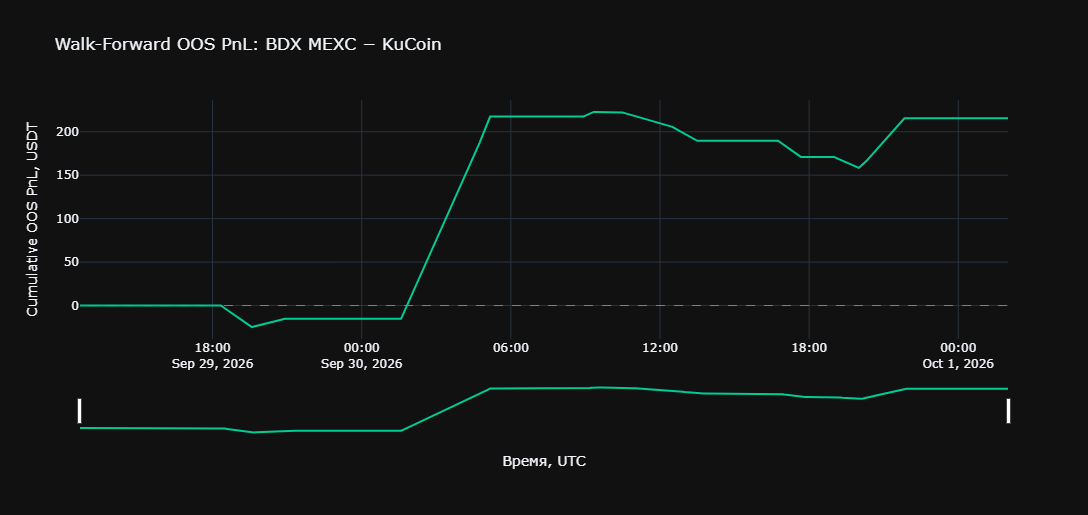

In [20]:
# Cumulative OOS PnL по времени.
cumulative_oos = (
    oos_pnl_bdx
    .groupby("datetime_utc")["equity_usdt"]
    .sum()
    .cumsum()
)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=cumulative_oos.index,
        y=cumulative_oos.values,
        mode="lines",
        name="OOS PnL",
        line=dict(color="#00CC96", width=2),
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Cumulative OOS PnL: %{y:.2f} USDT"
            "<extra></extra>"
        ),
    )
)

fig.add_hline(
    y=0,
    line_color="gray",
    line_width=1,
    line_dash="dash",
)

fig.update_layout(
    title="Walk-Forward OOS PnL: BDX MEXC − KuCoin",
    template="plotly_dark",
    height=500,
    dragmode="pan",
    hovermode="x unified",

    xaxis=dict(
        title="Время, UTC",
        type="date",
        rangeslider=dict(visible=True),
    ),

    yaxis=dict(
        title="Cumulative OOS PnL, USDT",
        zeroline=False,
    ),
)

fig.show(
    config={
        "scrollZoom": True,
        "displaylogo": False,
        "responsive": True,
    }
)

In [19]:
param_df = pd.DataFrame(param_history_bdx)

print("Статистика параметров по шагам WFO:")
print(
    param_df[
        [
            "window",
            "long_entry_z",
            "short_entry_z",
            "test_net_profit",
            "test_trade_count",
        ]
    ]
    .describe()
    .round(3)
)

print("\nРаспределение лучших window:")
print(param_df["window"].value_counts().sort_index())

print("\nРаспределение test_net_profit:")
print(
    param_df["test_net_profit"]
    .agg(["min", "max", "mean", "median", "std"])
    .round(4)
)

Статистика параметров по шагам WFO:
        window  long_entry_z  short_entry_z  test_net_profit  test_trade_count
count    8.000         8.000            8.0            8.000             8.000
mean    75.625        -1.812            1.5            0.911             1.375
std     49.888         0.259            0.0            2.450             1.061
min     45.000        -2.000            1.5           -1.682             0.000
25%     45.000        -2.000            1.5           -0.334             0.750
50%     65.000        -2.000            1.5            0.316             1.500
75%     68.750        -1.500            1.5            1.459             2.000
max    195.000        -1.500            1.5            5.948             3.000

Распределение лучших window:
window
45     3
65     3
80     1
195    1
Name: count, dtype: int64

Распределение test_net_profit:
min      -1.6815
max       5.9485
mean      0.9112
median    0.3163
std       2.4500
Name: test_net_profit, dtype: float64